# Uber Booking Status

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error


In [2]:
dataset = pd.read_csv(r"C:\Users\subas\OneDrive\Desktop\Uber Data Analysis Project\dataset\uber_dataset.csv")

In [3]:
df = dataset.copy()

In [4]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [5]:
df.shape

(150000, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [7]:
# Date Time conversion
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'])

df['hour'] = df['Time'].dt.hour
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month


C:\Users\subas\AppData\Local\Temp\ipykernel_7432\704537196.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


In [8]:
# Checking missing values
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
hour                                      0
day                             

In [9]:
# Null percentage for each column
for col in df.columns:
    print(f"{col}     null % :- \t \t {df[col].isna().sum()/df.shape[0] * 100:.2f}%")

Date     null % :- 	 	 0.00%
Time     null % :- 	 	 0.00%
Booking ID     null % :- 	 	 0.00%
Booking Status     null % :- 	 	 0.00%
Customer ID     null % :- 	 	 0.00%
Vehicle Type     null % :- 	 	 0.00%
Pickup Location     null % :- 	 	 0.00%
Drop Location     null % :- 	 	 0.00%
Avg VTAT     null % :- 	 	 7.00%
Avg CTAT     null % :- 	 	 32.00%
Cancelled Rides by Customer     null % :- 	 	 93.00%
Reason for cancelling by Customer     null % :- 	 	 93.00%
Cancelled Rides by Driver     null % :- 	 	 82.00%
Driver Cancellation Reason     null % :- 	 	 82.00%
Incomplete Rides     null % :- 	 	 94.00%
Incomplete Rides Reason     null % :- 	 	 94.00%
Booking Value     null % :- 	 	 32.00%
Ride Distance     null % :- 	 	 32.00%
Driver Ratings     null % :- 	 	 38.00%
Customer Rating     null % :- 	 	 38.00%
Payment Method     null % :- 	 	 32.00%
hour     null % :- 	 	 0.00%
day     null % :- 	 	 0.00%
month     null % :- 	 	 0.00%


In [10]:
# Null percentage for each column
print(f"{'Column Name':<25} {'Null %':>20}")
print("-" * 50)

for col in df.columns:
    null_pct = df[col].isna().sum() / df.shape[0] * 100
    print(f"{col:<25} {null_pct:>20.2f}%")

Column Name                             Null %
--------------------------------------------------
Date                                      0.00%
Time                                      0.00%
Booking ID                                0.00%
Booking Status                            0.00%
Customer ID                               0.00%
Vehicle Type                              0.00%
Pickup Location                           0.00%
Drop Location                             0.00%
Avg VTAT                                  7.00%
Avg CTAT                                 32.00%
Cancelled Rides by Customer                93.00%
Reason for cancelling by Customer                93.00%
Cancelled Rides by Driver                82.00%
Driver Cancellation Reason                82.00%
Incomplete Rides                         94.00%
Incomplete Rides Reason                  94.00%
Booking Value                            32.00%
Ride Distance                            32.00%
Driver Ratings             

In [11]:
null_summary = pd.DataFrame({
    "Column": df.columns,
    "Null Count": df.isna().sum().values,
    "Null %": (df.isna().sum() / len(df) * 100).round(2).values
}).sort_values("Null %", ascending=False)

print(null_summary)

                               Column  Null Count  Null %
15            Incomplete Rides Reason      141000    94.0
14                   Incomplete Rides      141000    94.0
10        Cancelled Rides by Customer      139500    93.0
11  Reason for cancelling by Customer      139500    93.0
12          Cancelled Rides by Driver      123000    82.0
13         Driver Cancellation Reason      123000    82.0
19                    Customer Rating       57000    38.0
18                     Driver Ratings       57000    38.0
20                     Payment Method       48000    32.0
17                      Ride Distance       48000    32.0
9                            Avg CTAT       48000    32.0
16                      Booking Value       48000    32.0
8                            Avg VTAT       10500     7.0
22                                day           0     0.0
21                               hour           0     0.0
0                                Date           0     0.0
1             

##### Drop columns

In [12]:
# Drop those columns which have more than 50% null values and unuseful columns
df.drop(columns=['Date','Time','Incomplete Rides Reason',
                 'Incomplete Rides','Cancelled Rides by Customer',
                 'Reason for cancelling by Customer','Cancelled Rides by Driver',
                 'Driver Cancellation Reason','Booking ID','Customer ID'],inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Booking Status   150000 non-null  object 
 1   Vehicle Type     150000 non-null  object 
 2   Pickup Location  150000 non-null  object 
 3   Drop Location    150000 non-null  object 
 4   Avg VTAT         139500 non-null  float64
 5   Avg CTAT         102000 non-null  float64
 6   Booking Value    102000 non-null  float64
 7   Ride Distance    102000 non-null  float64
 8   Driver Ratings   93000 non-null   float64
 9   Customer Rating  93000 non-null   float64
 10  Payment Method   102000 non-null  object 
 11  hour             150000 non-null  int32  
 12  day              150000 non-null  int32  
 13  month            150000 non-null  int32  
dtypes: float64(6), int32(3), object(5)
memory usage: 14.3+ MB


In [14]:
df['Booking Status'].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

In [15]:
# Jaha Booking Status 'Completed' nahi hai, waha Ride Distance, Booking Value, Driver Ratings, Customer Rating ko 0 kar diya
df.loc[df['Booking Status'] != 'Completed',
       ['Ride Distance','Booking Value','Driver Ratings','Customer Rating']] = 0

In [16]:
df['Booking Status'].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Booking Status   150000 non-null  object 
 1   Vehicle Type     150000 non-null  object 
 2   Pickup Location  150000 non-null  object 
 3   Drop Location    150000 non-null  object 
 4   Avg VTAT         139500 non-null  float64
 5   Avg CTAT         102000 non-null  float64
 6   Booking Value    150000 non-null  float64
 7   Ride Distance    150000 non-null  float64
 8   Driver Ratings   150000 non-null  float64
 9   Customer Rating  150000 non-null  float64
 10  Payment Method   102000 non-null  object 
 11  hour             150000 non-null  int32  
 12  day              150000 non-null  int32  
 13  month            150000 non-null  int32  
dtypes: float64(6), int32(3), object(5)
memory usage: 14.3+ MB


##### Filling missing values

In [18]:
# num_cols = ['Avg VTAT','Avg CTAT','Booking Value','Ride Distance',
#             'Driver Ratings','Customer Rating']
# df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# df['Payment Method'] = df['Payment Method'].fillna(df['Payment Method'].mode()[0])

In [19]:
# Payment Method
df['Payment Method'] = df['Payment Method'].fillna('No Payment')

# Avg VTAT
df['Avg VTAT'] = df['Avg VTAT'].fillna(df['Avg VTAT'].median())

# Avg CTAT
df['Avg CTAT'] = df['Avg CTAT'].fillna(0)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Booking Status   150000 non-null  object 
 1   Vehicle Type     150000 non-null  object 
 2   Pickup Location  150000 non-null  object 
 3   Drop Location    150000 non-null  object 
 4   Avg VTAT         150000 non-null  float64
 5   Avg CTAT         150000 non-null  float64
 6   Booking Value    150000 non-null  float64
 7   Ride Distance    150000 non-null  float64
 8   Driver Ratings   150000 non-null  float64
 9   Customer Rating  150000 non-null  float64
 10  Payment Method   150000 non-null  object 
 11  hour             150000 non-null  int32  
 12  day              150000 non-null  int32  
 13  month            150000 non-null  int32  
dtypes: float64(6), int32(3), object(5)
memory usage: 14.3+ MB


In [21]:
df.describe()

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,hour,day,month
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,8.445407,19.821753,315.070493,16.120306,2.623215,2.730842,14.034113,15.646087,6.490940
std,3.639311,15.452834,397.614554,16.666106,2.082283,2.165548,5.416906,8.781698,3.444028
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,5.600000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,8.000000,3.000000
50%,8.300000,22.000000,194.000000,11.350000,3.900000,4.100000,15.000000,16.000000,7.000000
75%,11.000000,32.900000,485.000000,30.650000,4.300000,4.600000,18.000000,23.000000,9.000000
max,20.000000,45.000000,4277.000000,50.000000,5.000000,5.000000,23.000000,31.000000,12.000000


##### Check duplicates Values

In [22]:
df.duplicated().sum()

0

In [23]:
df[df['Ride Distance'] == 0]

,Booking Status,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,hour,day,month
0,No Driver Found,eBike,Palam Vihar,Jhilmil,8.3,0.0,0.0,0.0,0.0,0.0,No Payment,12,23,3
1,Incomplete,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0.0,0.0,0.0,0.0,UPI,18,29,11
8,No Driver Found,Go Sedan,Noida Sector 62,Noida Sector 18,8.3,0.0,0.0,0.0,0.0,0.0,No Payment,12,14,9
9,Incomplete,Auto,Rohini,Adarsh Nagar,6.1,26.0,0.0,0.0,0.0,0.0,Cash,19,16,12
11,No Driver Found,Auto,Vidhan Sabha,AIIMS,8.3,0.0,0.0,0.0,0.0,0.0,No Payment,8,18,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149980,No Driver Found,Premier Sedan,Kirti Nagar,Sarojini Nagar,8.3,0.0,0.0,0.0,0.0,0.0,No Payment,15,10,12
149982,No Driver Found,Auto,Sikanderpur,Old Gurgaon,8.3,0.0,0.0,0.0,0.0,0.0,No Payment,6,13,11
149984,Incomplete,Go Sedan,Azadpur,Lajpat Nagar,5.9,12.8,0.0,0.0,0.0,0.0,Cash,15,14,1
149990,Cancelled by Driver,Auto,Kashmere Gate ISBT,GTB Nagar,10.7,0.0,0.0,0.0,0.0,0.0,No Payment,12,26,9


##### Checking Unique Values

In [24]:
print(df['Booking Status'].unique())
print(df['Vehicle Type'].unique())
print(df['Payment Method'].unique())
# All are good, no need to change the data types.

['No Driver Found' 'Incomplete' 'Completed' 'Cancelled by Driver'
 'Cancelled by Customer']
['eBike' 'Go Sedan' 'Auto' 'Premier Sedan' 'Bike' 'Go Mini' 'Uber XL']
['No Payment' 'UPI' 'Debit Card' 'Cash' 'Uber Wallet' 'Credit Card']


#### Feature Engineering

In [25]:
df['time_period'] = pd.cut(
    df['hour'],
    bins=[0,6,12,18,24],
    labels=['Night','Morning','Afternoon','Evening'],
    right=False
)

In [26]:
df.isna().sum()

Booking Status     0
Vehicle Type       0
Pickup Location    0
Drop Location      0
Avg VTAT           0
Avg CTAT           0
Booking Value      0
Ride Distance      0
Driver Ratings     0
Customer Rating    0
Payment Method     0
hour               0
day                0
month              0
time_period        0
dtype: int64

## Data Vizualization

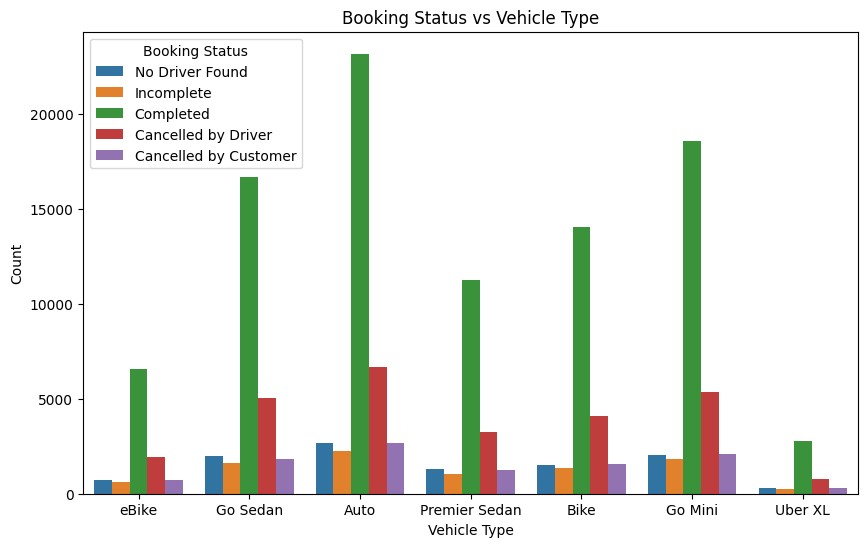

In [27]:
# Booking status vs vehicle type => Countplot
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Vehicle Type', hue='Booking Status')
plt.title('Booking Status vs Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Count')
plt.legend(title='Booking Status')
plt.show()

In [28]:
df['Booking Status'].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

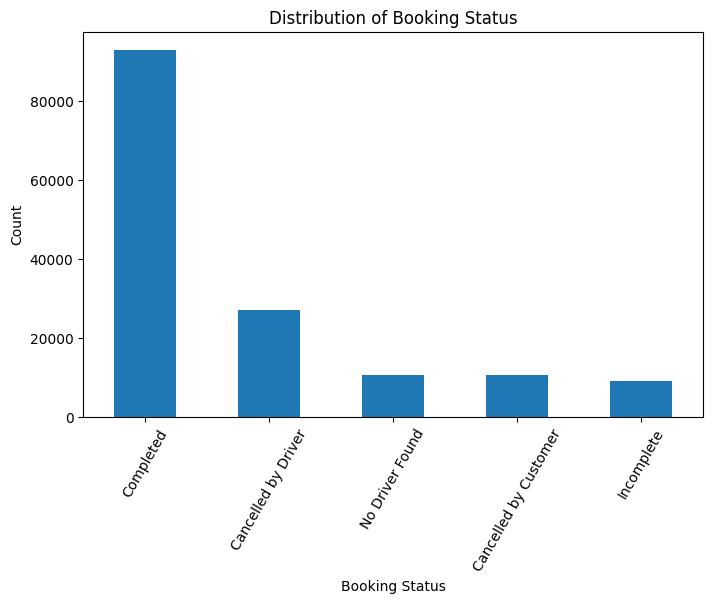

In [29]:
# Bar chart for booking status
plt.figure(figsize=(8,5))
df['Booking Status'].value_counts().plot(kind='bar')
plt.xlabel('Booking Status')
plt.xticks(rotation=60)
plt.ylabel('Count')
plt.title('Distribution of Booking Status')
plt.show()

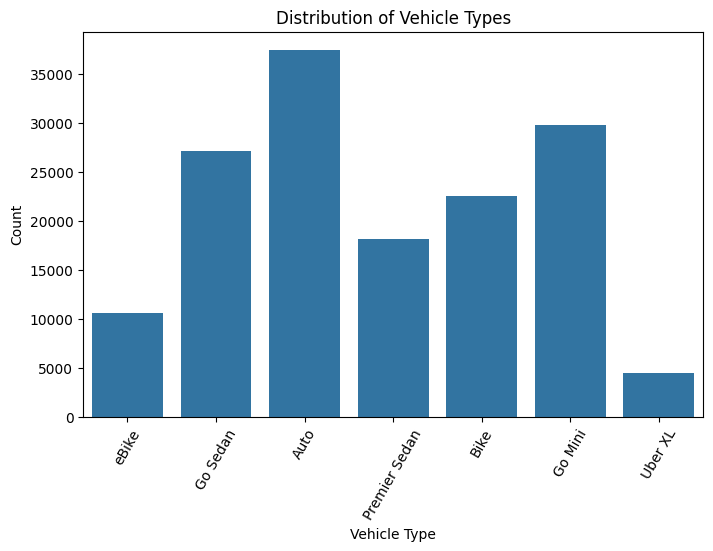

In [30]:
# Bar chart for Vehicle Type
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Count')
plt.title('Distribution of Vehicle Types')
plt.xticks(rotation=60)
plt.show()

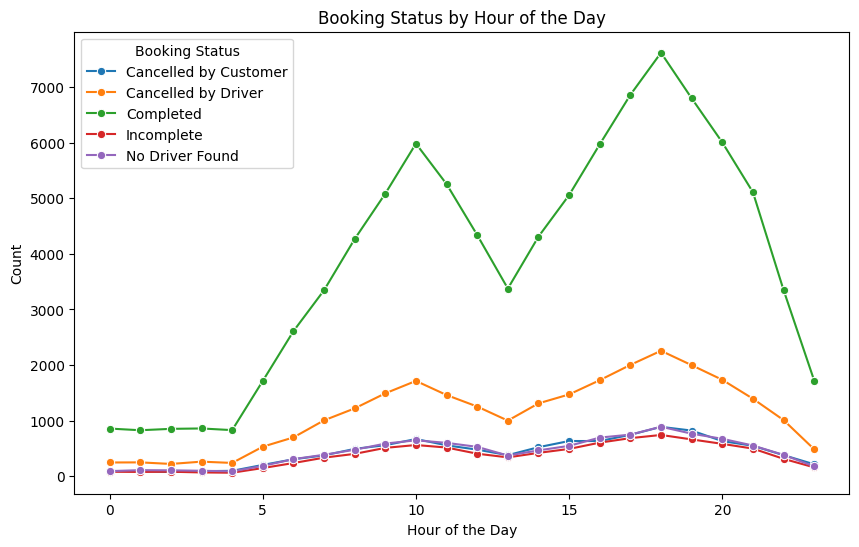

In [31]:
# Count bookings by hour and status
hourly = df.groupby(['hour', 'Booking Status']).size().reset_index(name='count')

plt.figure(figsize=(10,6))
sns.lineplot(data=hourly, x='hour', y='count', hue='Booking Status', marker='o')
plt.title('Booking Status by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Count')
plt.legend(title='Booking Status')
plt.show()

In [32]:
df.groupby(['hour', 'Booking Status']).size().reset_index(name='count')

,hour,Booking Status,count
0,0,Cancelled by Customer,92
1,0,Cancelled by Driver,248
2,0,Completed,858
3,0,Incomplete,82
4,0,No Driver Found,93
...,...,...,...
115,23,Cancelled by Customer,216
116,23,Cancelled by Driver,486
117,23,Completed,1722
118,23,Incomplete,160


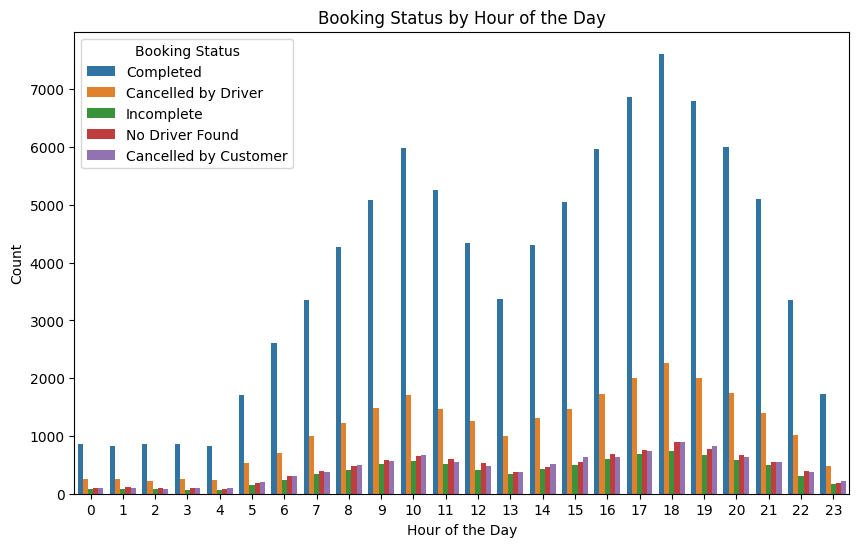

In [33]:
# Count plot
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='hour', hue='Booking Status')
plt.title('Booking Status by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Count')
plt.legend(title='Booking Status')
plt.show()

##### Cross Tab

In [34]:
# Cross tab
pd.crosstab(df['Booking Status'], df['Vehicle Type'])

Vehicle Type,Auto,Bike,Go Mini,Go Sedan,Premier Sedan,Uber XL,eBike
Booking Status,,,,,,,
Cancelled by Customer,2680,1575,2097,1832,1266,327,723
Cancelled by Driver,6643,4077,5330,5031,3250,762,1907
Completed,23155,14034,18549,16676,11252,2783,6551
Incomplete,2260,1328,1815,1642,1063,262,630
No Driver Found,2681,1503,2015,1960,1280,315,746


In [35]:
# Percentage crosstab
pd.crosstab(df['Booking Status'], df['hour'], normalize='index') * 100

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Booking Status,,,,,,,,,,,,,,,,,,,,,
Cancelled by Customer,0.876190,0.895238,0.714286,0.876190,0.933333,1.942857,2.914286,3.580952,4.695238,5.323810,...,4.980952,6.038095,6.038095,7.104762,8.466667,7.828571,6.028571,5.219048,3.619048,2.057143
Cancelled by Driver,0.918519,0.925926,0.822222,0.974074,0.888889,1.970370,2.588889,3.725926,4.522222,5.525926,...,4.855556,5.451852,6.400000,7.418519,8.359259,7.400000,6.425926,5.166667,3.744444,1.800000
Completed,0.922581,0.890323,0.917204,0.924731,0.892473,1.844086,2.805376,3.597849,4.588172,5.466667,...,4.634409,5.437634,6.419355,7.376344,8.190323,7.309677,6.456989,5.493548,3.603226,1.851613
Incomplete,0.911111,0.866667,0.911111,0.766667,0.711111,1.644444,2.644444,3.722222,4.477778,5.677778,...,4.677778,5.466667,6.722222,7.622222,8.255556,7.366667,6.477778,5.533333,3.488889,1.777778
No Driver Found,0.885714,1.047619,1.019048,0.942857,0.847619,1.780952,2.933333,3.685714,4.542857,5.600000,...,4.438095,5.209524,6.628571,7.133333,8.485714,7.295238,6.419048,5.266667,3.666667,1.695238


In [36]:
pd.crosstab(df['Booking Status'], df['hour'])

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Booking Status,,,,,,,,,,,,,,,,,,,,,
Cancelled by Customer,92,94,75,92,98,204,306,376,493,559,...,523,634,634,746,889,822,633,548,380,216
Cancelled by Driver,248,250,222,263,240,532,699,1006,1221,1492,...,1311,1472,1728,2003,2257,1998,1735,1395,1011,486
Completed,858,828,853,860,830,1715,2609,3346,4267,5084,...,4310,5057,5970,6860,7617,6798,6005,5109,3351,1722
Incomplete,82,78,82,69,64,148,238,335,403,511,...,421,492,605,686,743,663,583,498,314,160
No Driver Found,93,110,107,99,89,187,308,387,477,588,...,466,547,696,749,891,766,674,553,385,178


In [37]:
df.columns

Index(['Booking Status', 'Vehicle Type', 'Pickup Location', 'Drop Location',
       'Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method', 'hour', 'day',
       'month', 'time_period'],
      dtype='object')

In [38]:
pd.crosstab(df['Booking Status'], df['time_period'], normalize='index') * 100

time_period,Night,Morning,Afternoon,Evening
Booking Status,,,,
Cancelled by Customer,6.238095,28.200000,32.342857,33.219048
Cancelled by Driver,6.500000,28.125926,32.477778,32.896296
Completed,6.391398,28.540860,32.162366,32.905376
Incomplete,5.811111,28.511111,32.777778,32.900000
No Driver Found,6.523810,28.647619,32.000000,32.828571


### Pie  chart

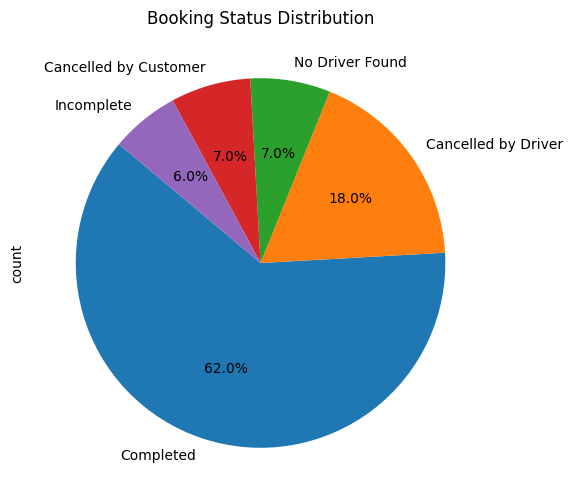

In [39]:
# Pie chart for booking status
plt.figure(figsize=(6,6))
df['Booking Status'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Booking Status Distribution')
plt.show()

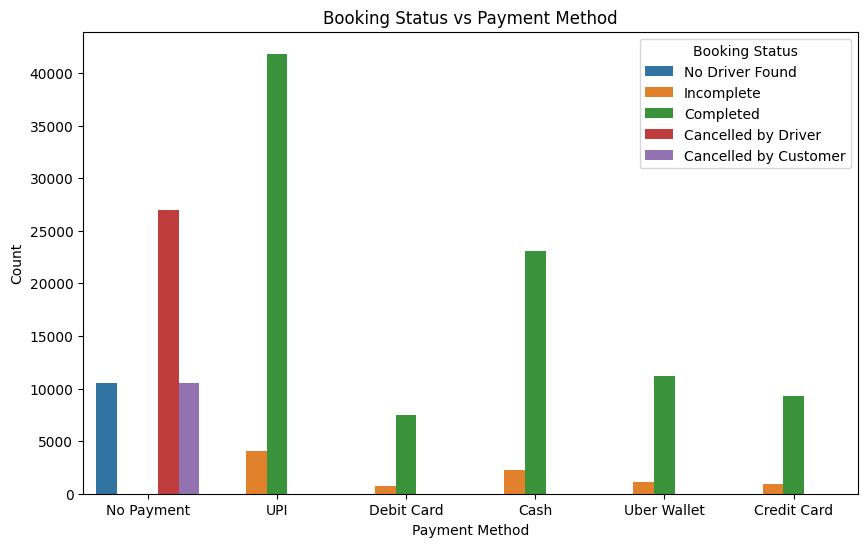

In [40]:
# Booking status vs Payment method => Countplot
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Payment Method', hue='Booking Status')
plt.title('Booking Status vs Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.legend(title='Booking Status')
plt.show()

C:\Users\subas\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


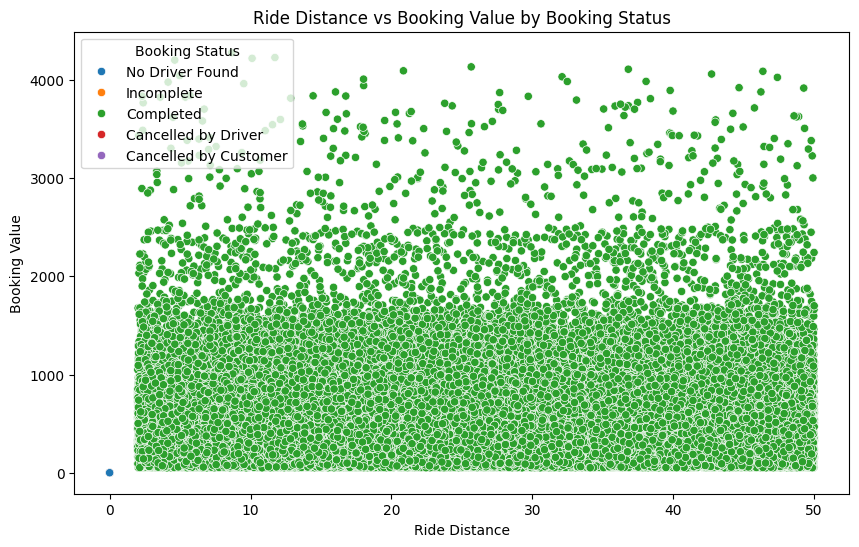

In [41]:
# Scatterplot for distance VS booking value
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Ride Distance', y='Booking Value', hue='Booking Status')
plt.title('Ride Distance vs Booking Value by Booking Status')
plt.xlabel('Ride Distance')
plt.ylabel('Booking Value')
plt.show()

C:\Users\subas\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


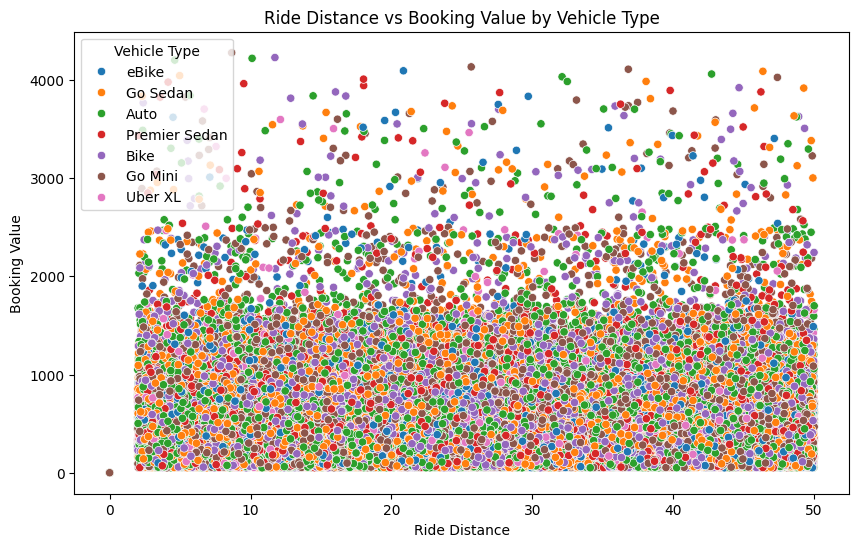

In [42]:
# Scatterplot for distance VS booking value
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Ride Distance', y='Booking Value', hue='Vehicle Type')
plt.title('Ride Distance vs Booking Value by Vehicle Type')
plt.xlabel('Ride Distance')
plt.ylabel('Booking Value')
plt.show()

In [43]:
pd.crosstab(df['Booking Status'], df['Vehicle Type'], margins=True)

Vehicle Type,Auto,Bike,Go Mini,Go Sedan,Premier Sedan,Uber XL,eBike,All
Booking Status,,,,,,,,
Cancelled by Customer,2680,1575,2097,1832,1266,327,723,10500
Cancelled by Driver,6643,4077,5330,5031,3250,762,1907,27000
Completed,23155,14034,18549,16676,11252,2783,6551,93000
Incomplete,2260,1328,1815,1642,1063,262,630,9000
No Driver Found,2681,1503,2015,1960,1280,315,746,10500
All,37419,22517,29806,27141,18111,4449,10557,150000


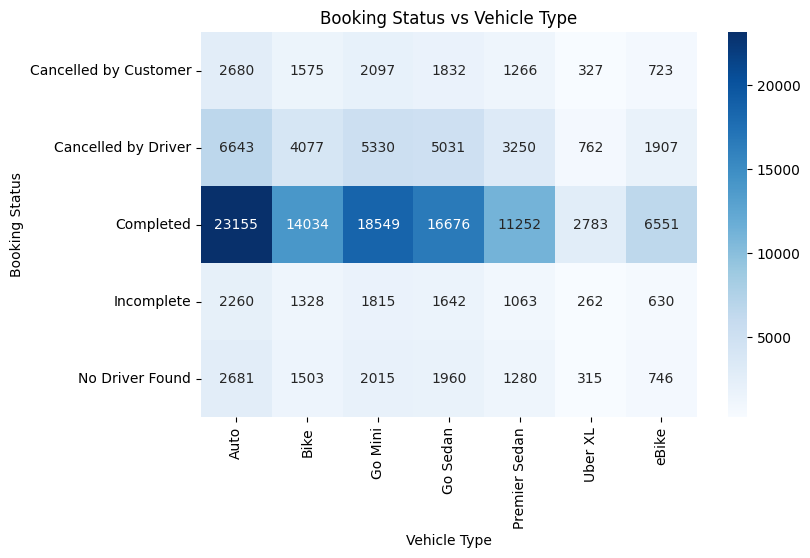

In [44]:
ct = pd.crosstab(df['Booking Status'], df['Vehicle Type'])

plt.figure(figsize=(8,5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Booking Status vs Vehicle Type')
plt.show()

### Normal Gaussian Distribution

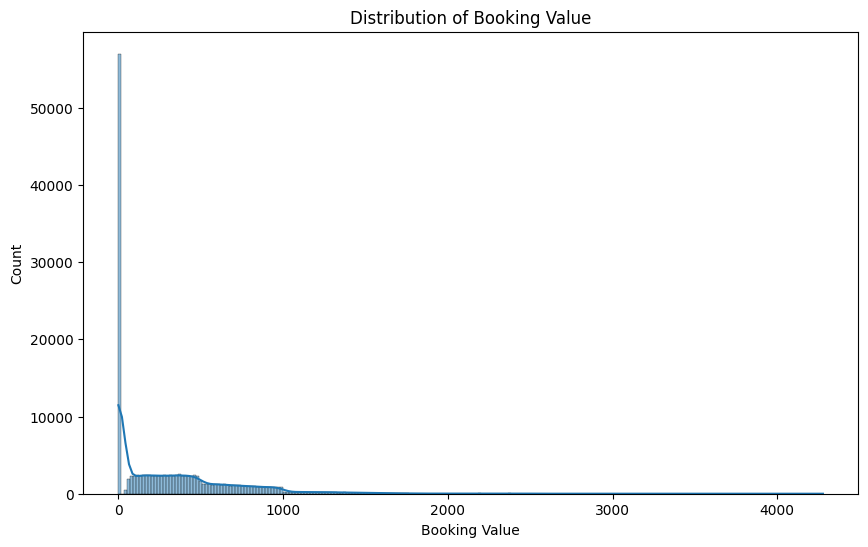

In [45]:
# Gaussian Distribution checking by plotting histogram and KDE plot
plt.figure(figsize=(10,6))
sns.histplot(df['Booking Value'], kde=True)
plt.title('Distribution of Booking Value')
plt.xlabel('Booking Value')
plt.show()

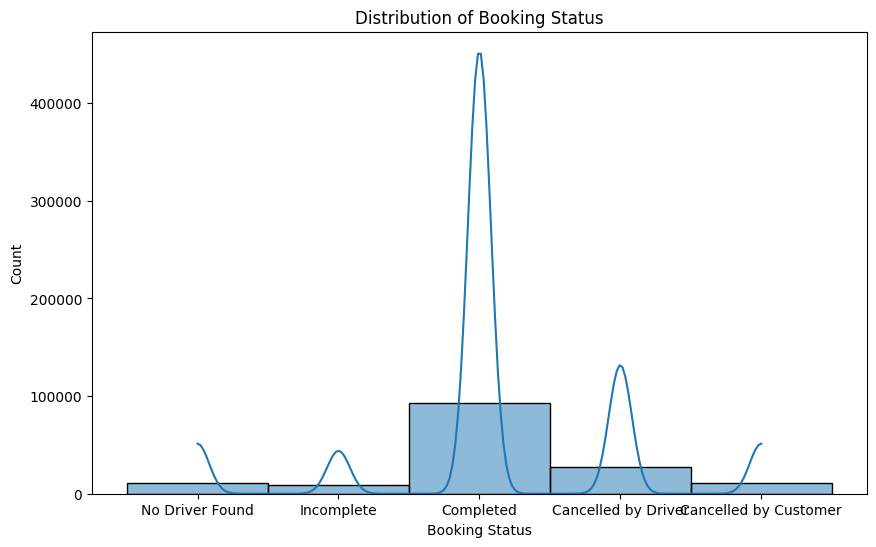

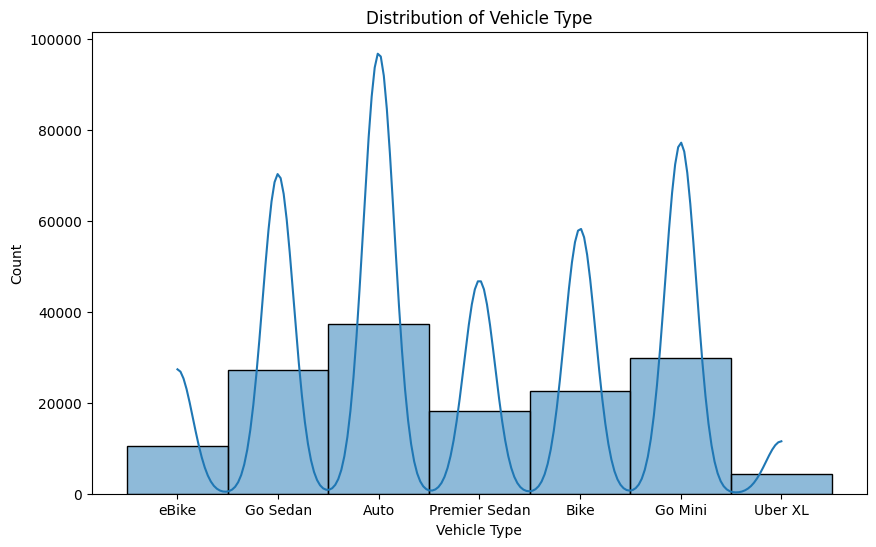

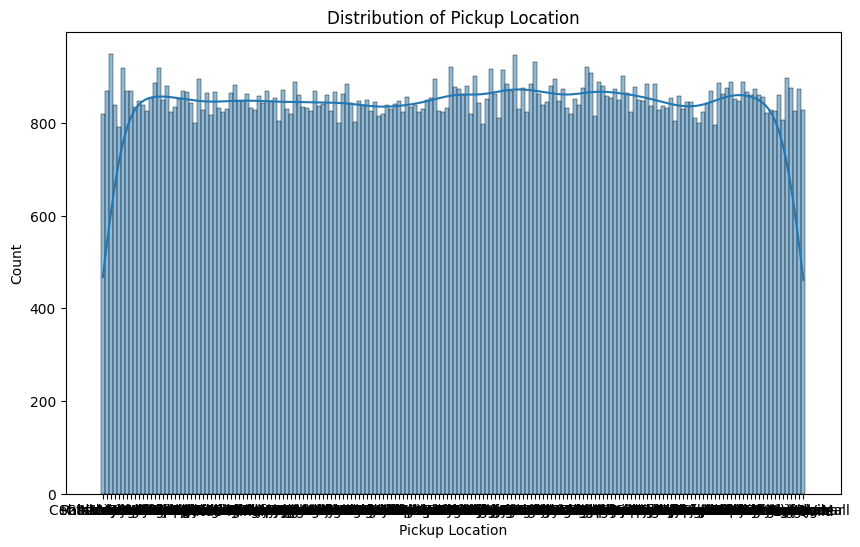

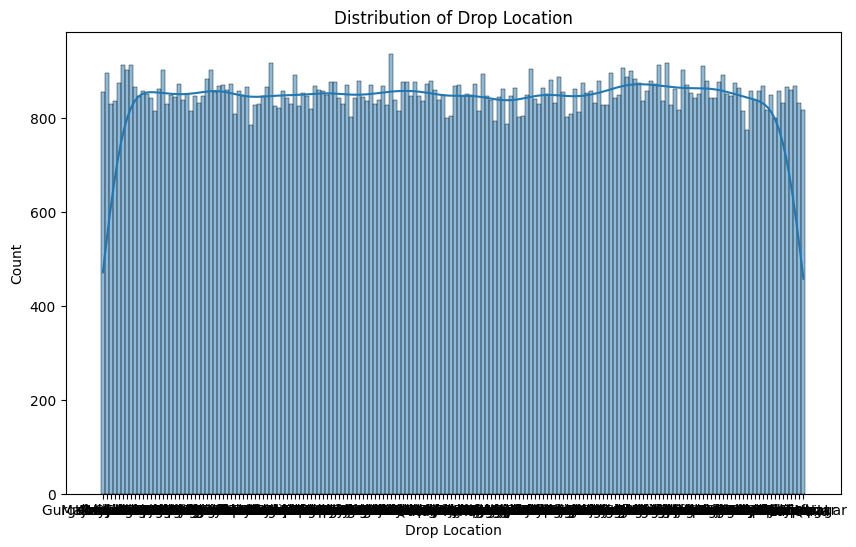

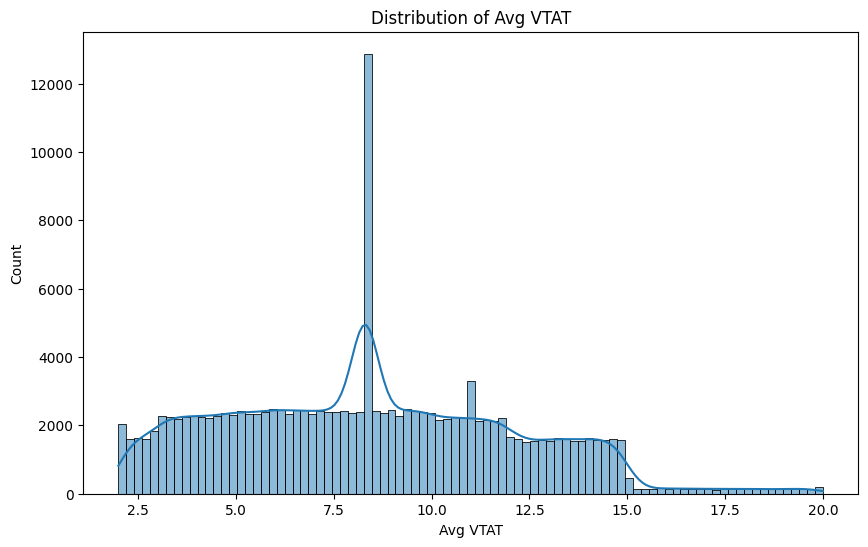

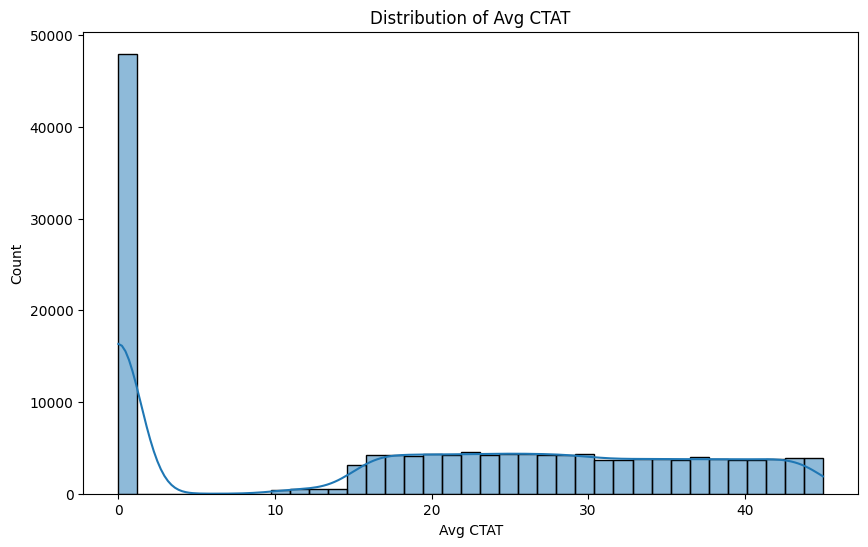

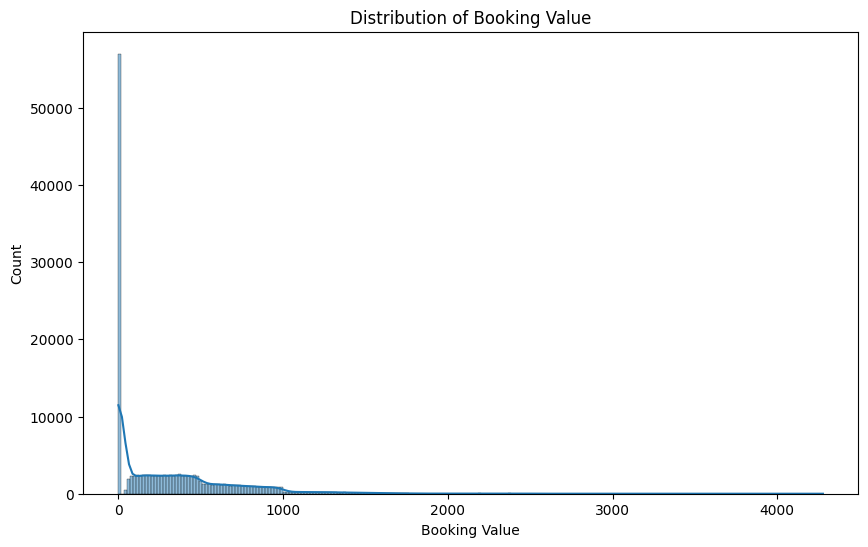

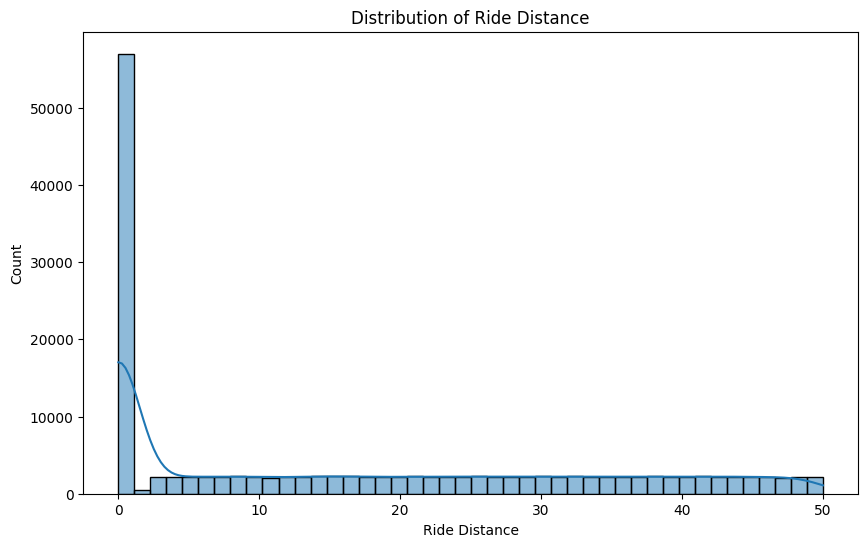

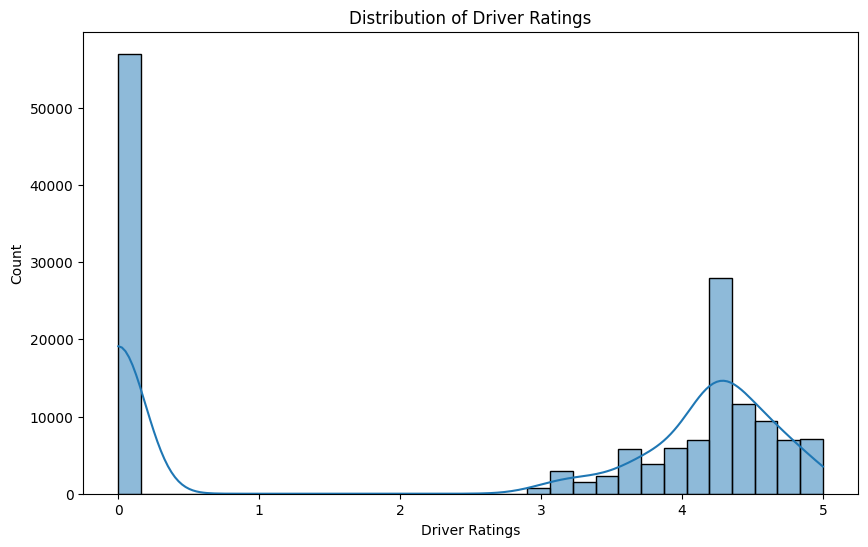

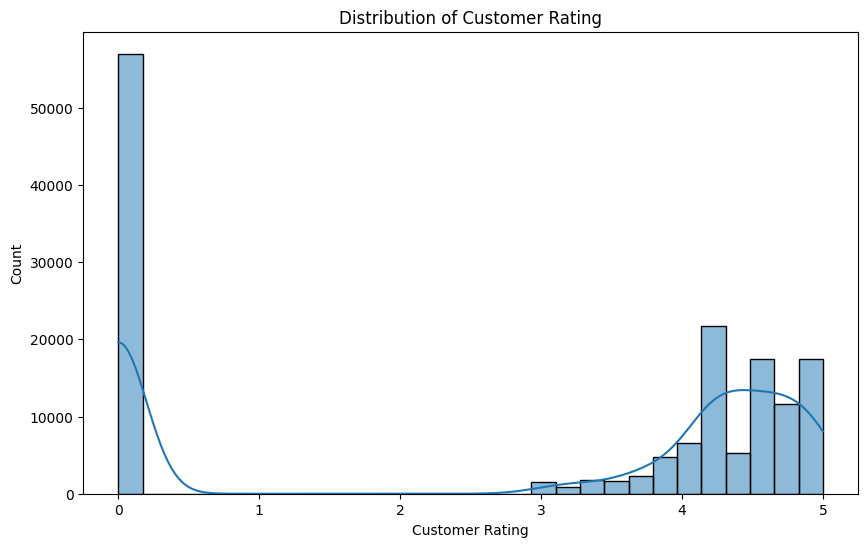

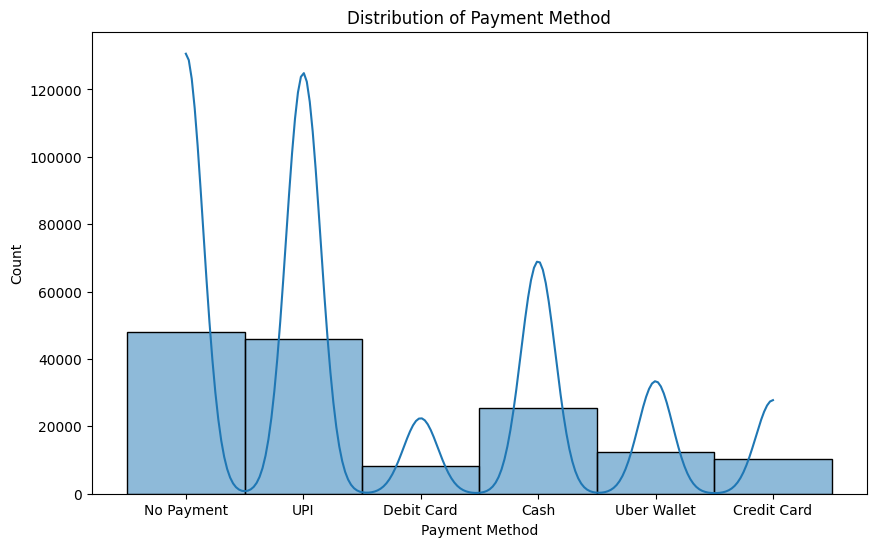

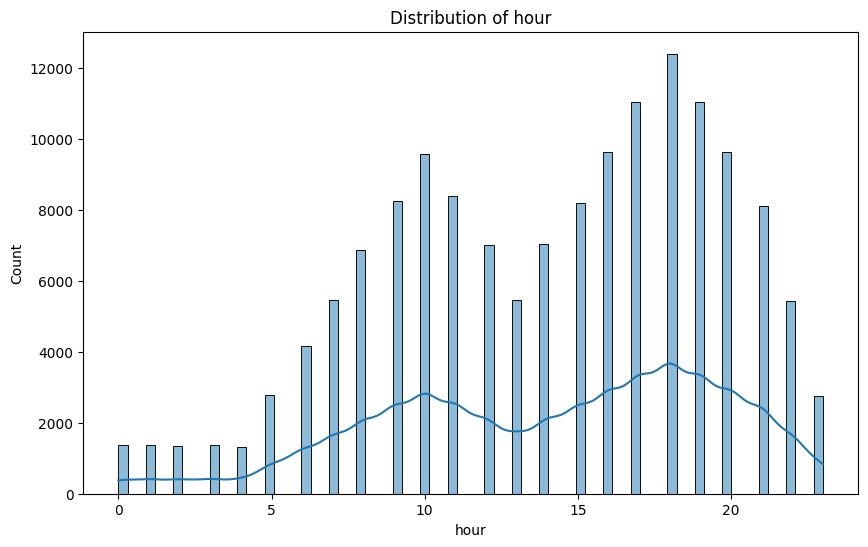

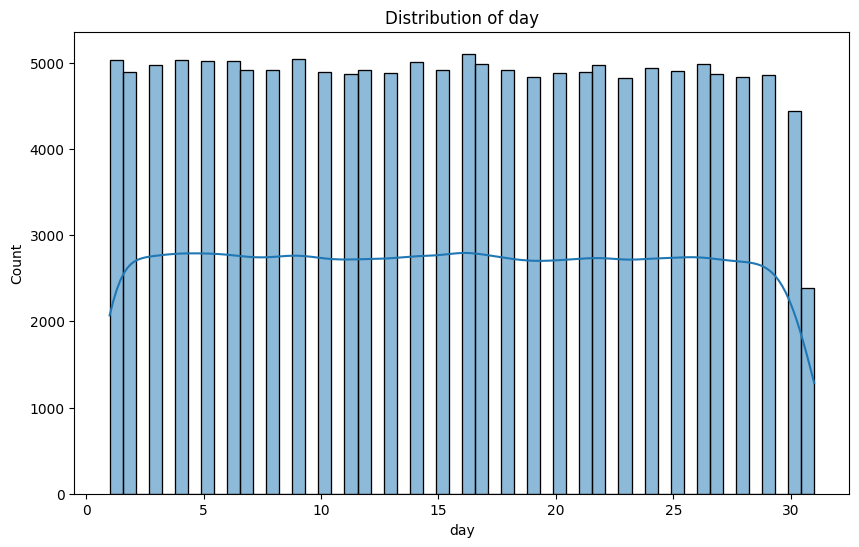

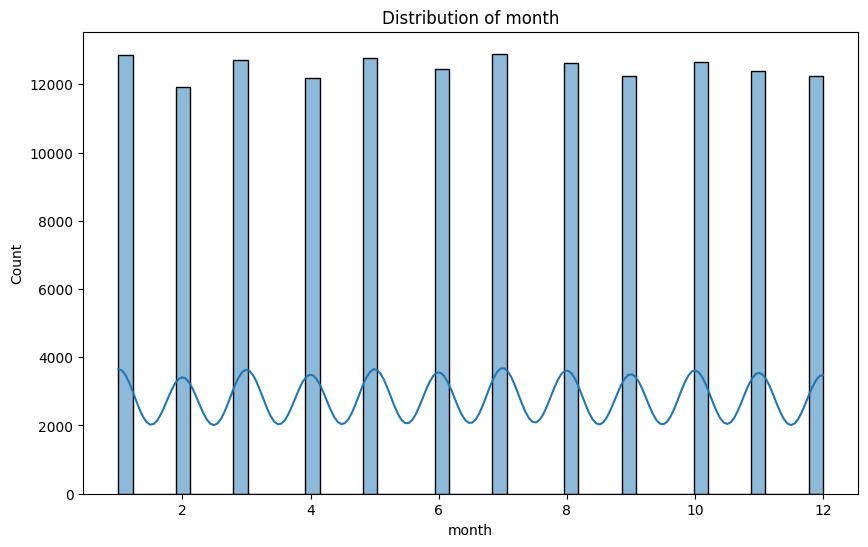

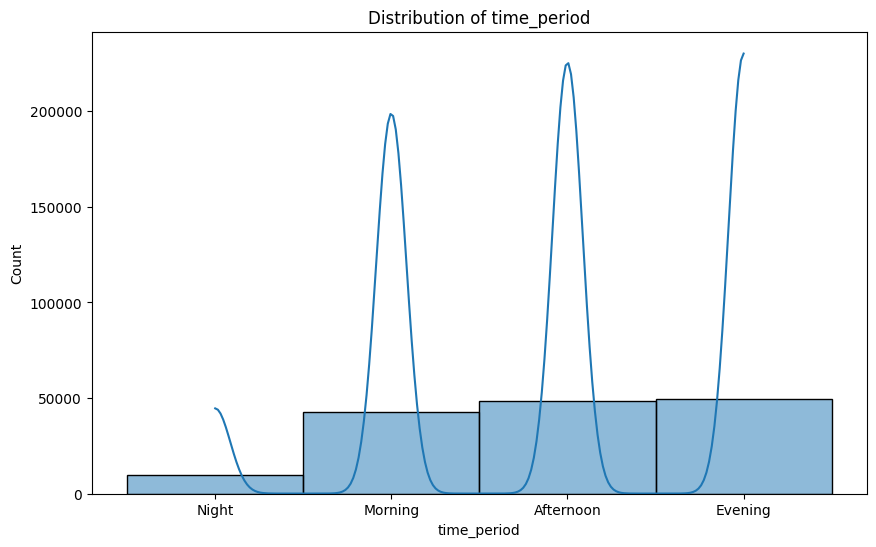

In [46]:
for col in df.columns:
    plt.figure(figsize=(10,6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.show()

### Box plot 

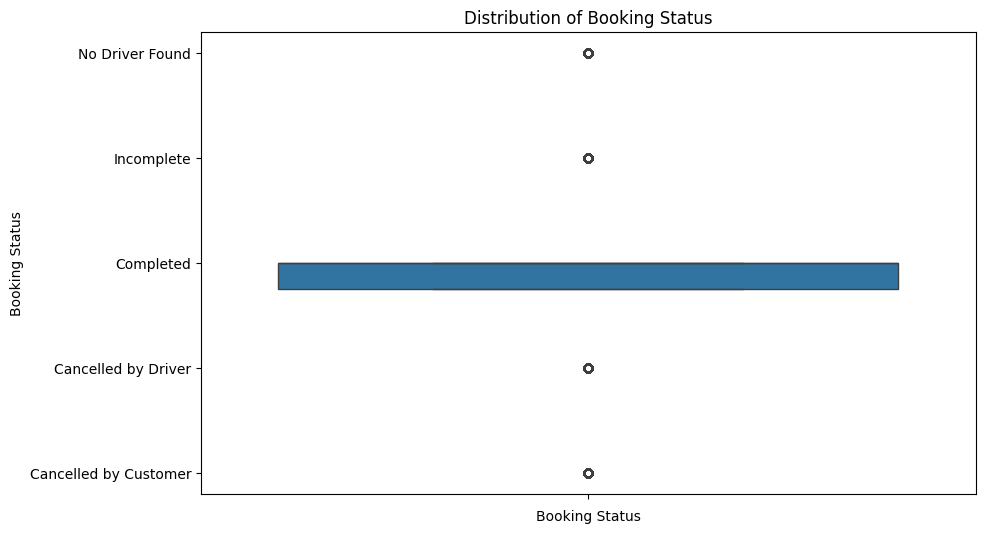

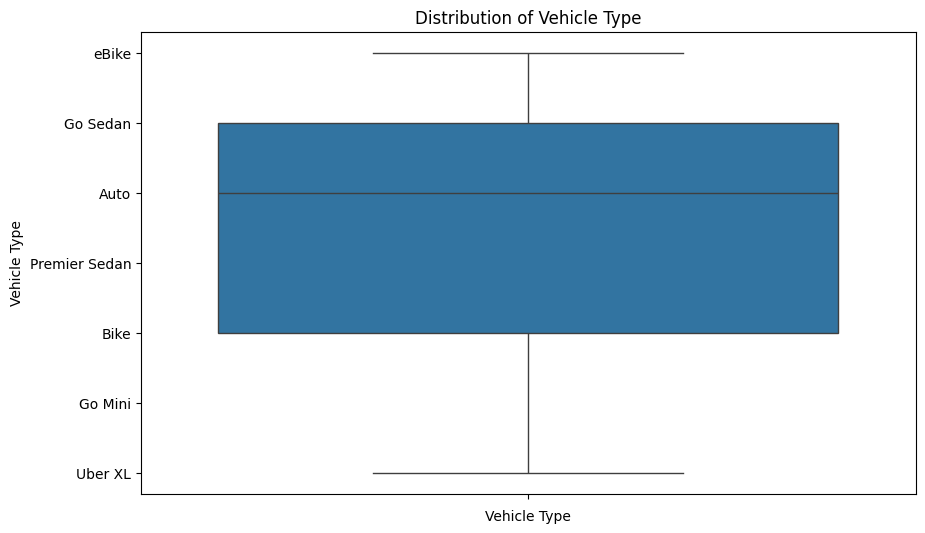

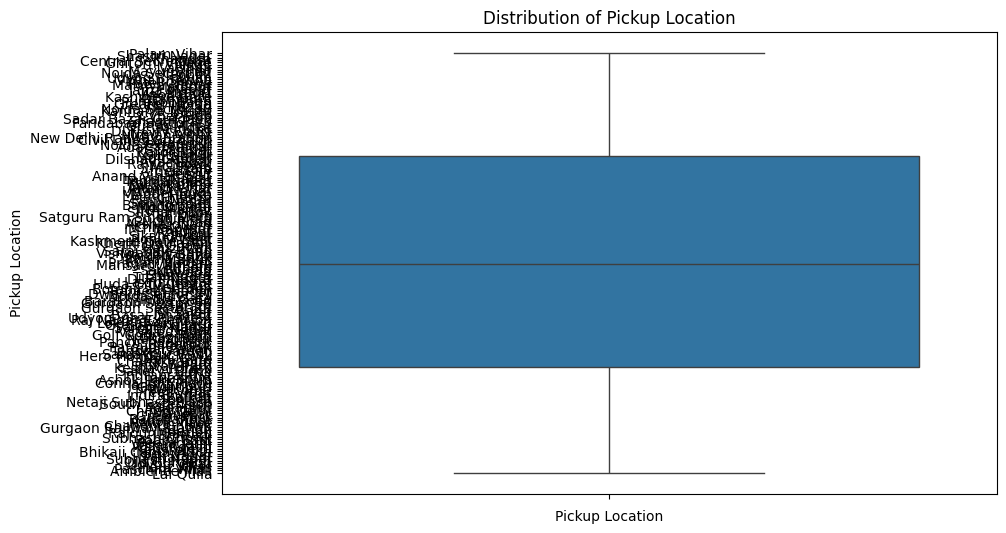

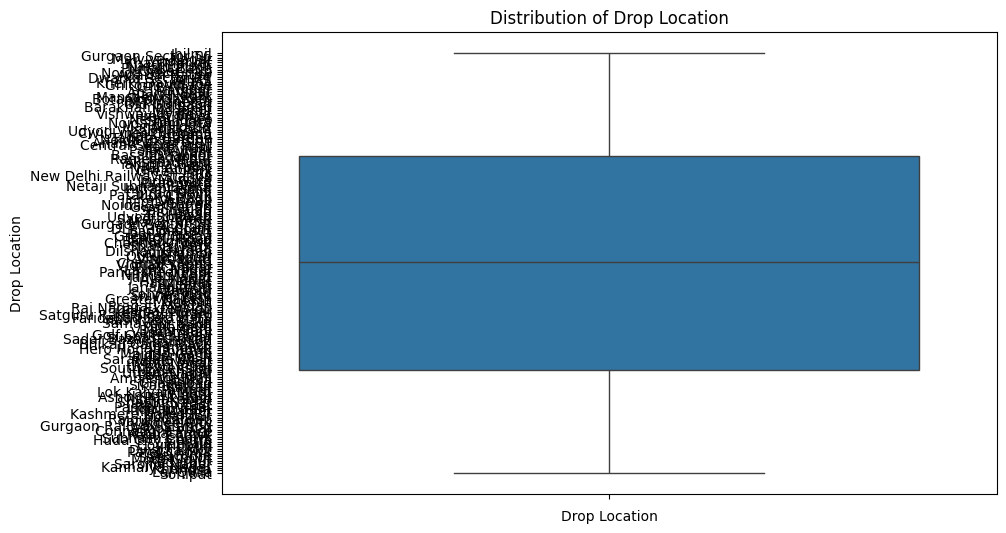

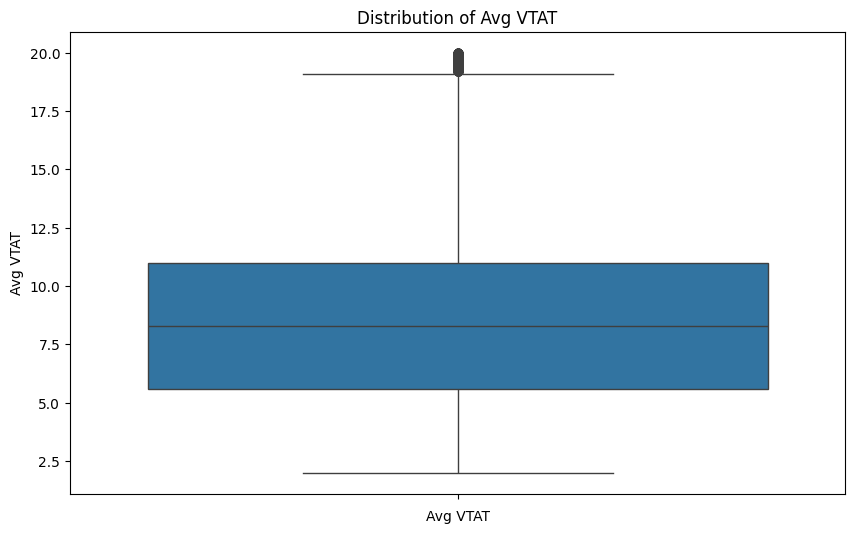

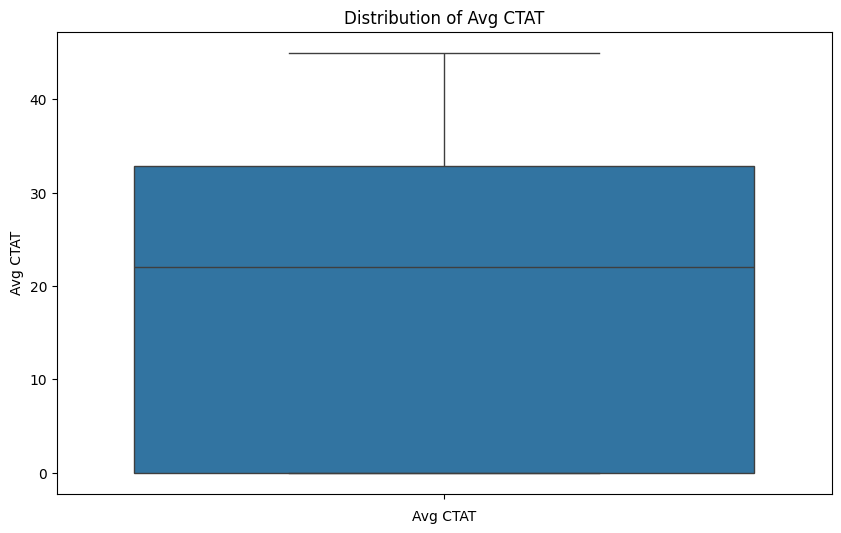

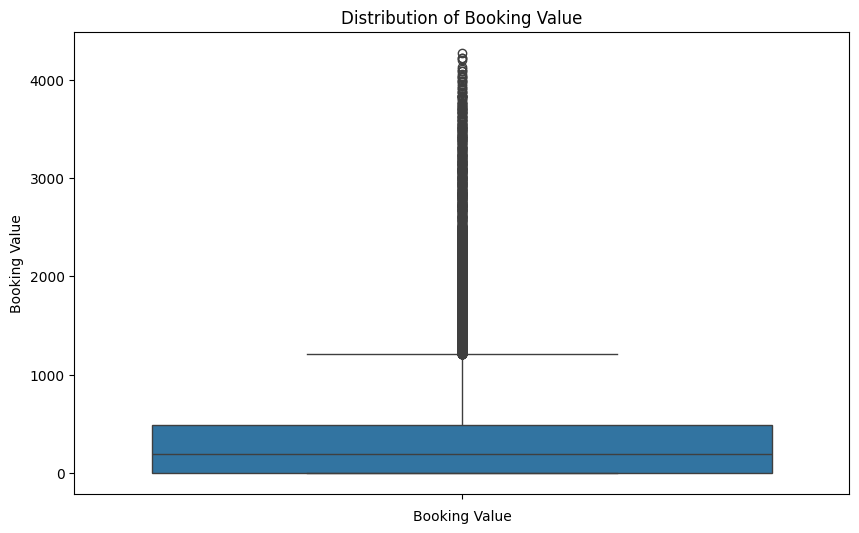

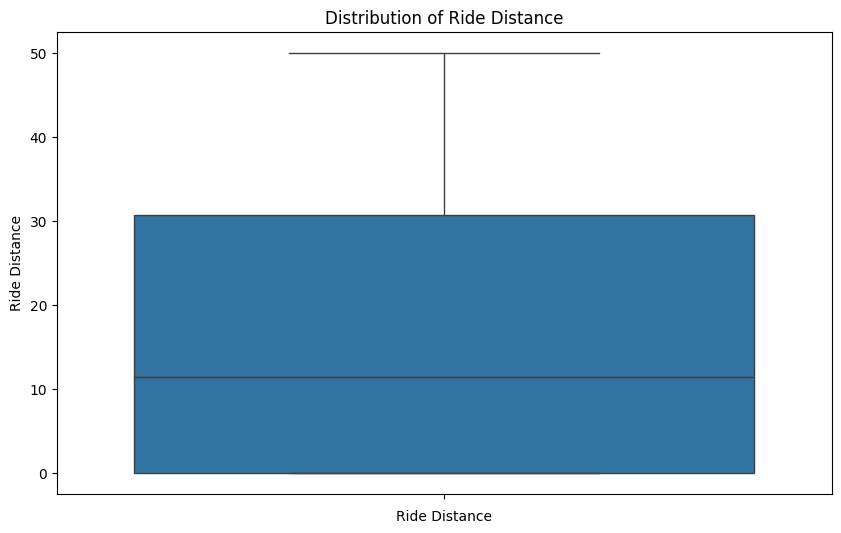

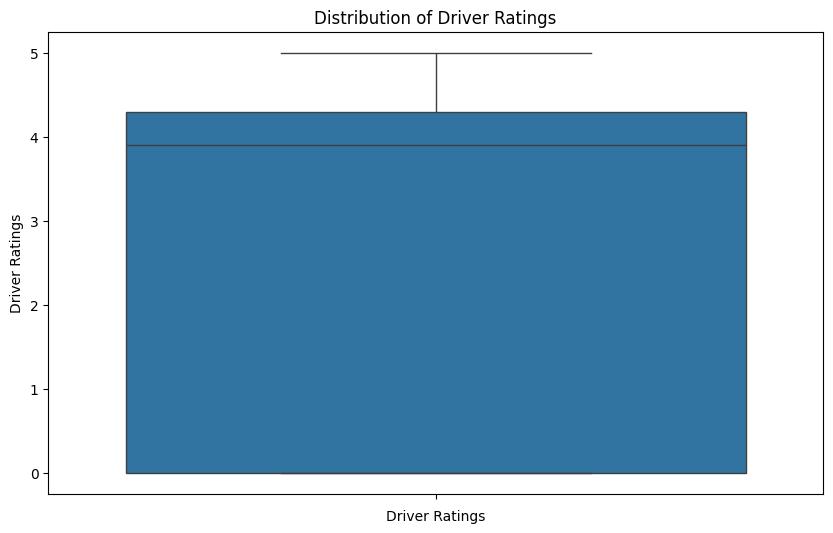

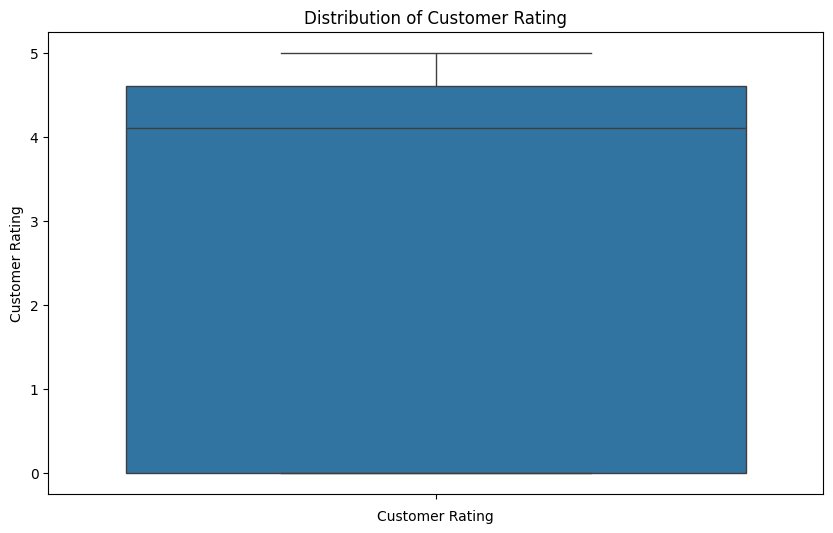

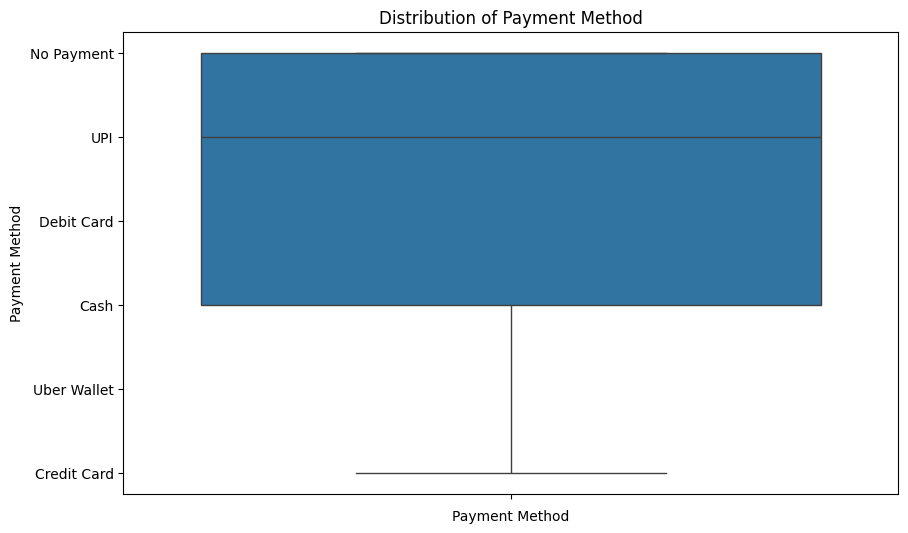

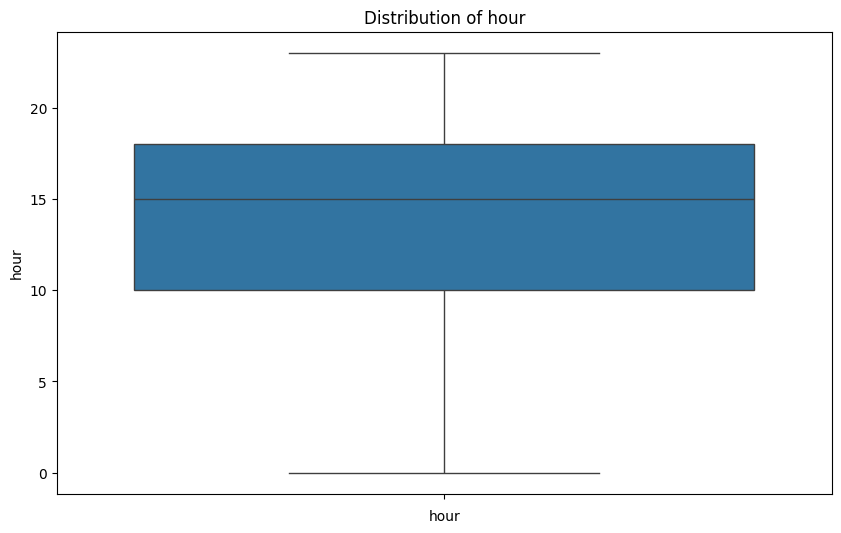

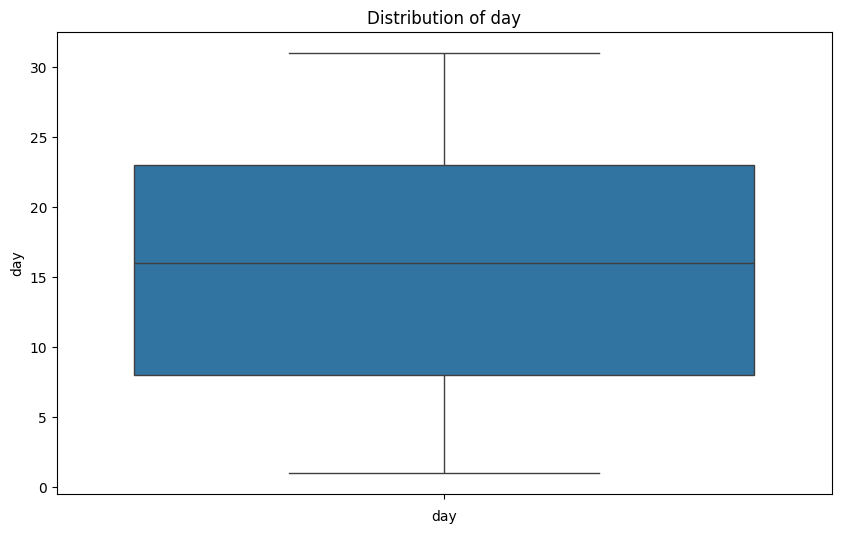

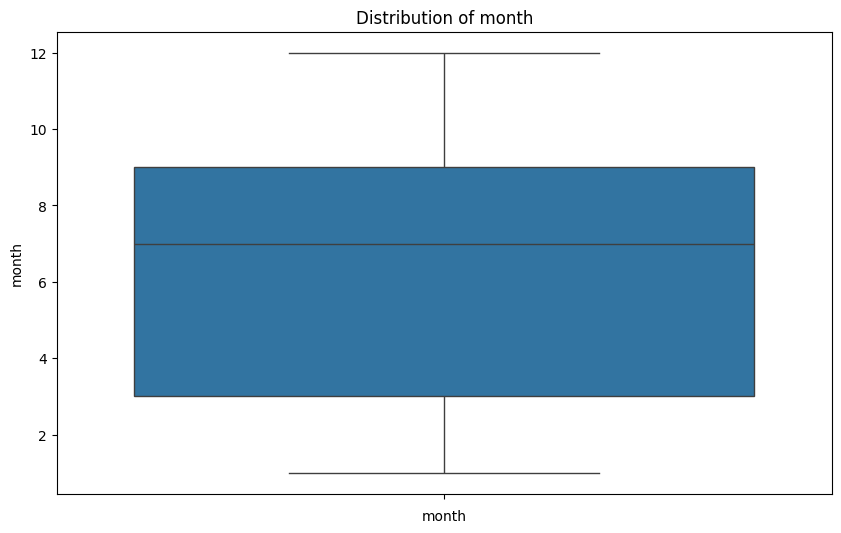

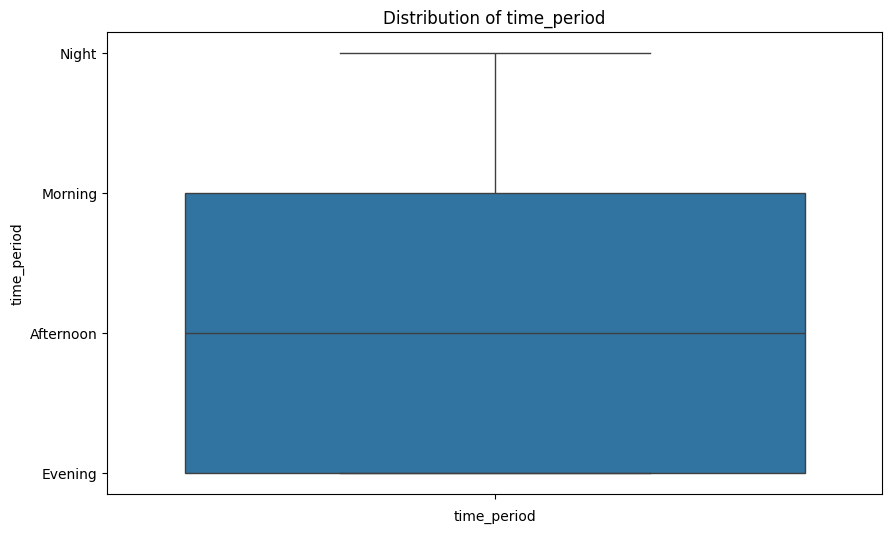

In [47]:
for col in df.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(df[col])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.show()

In [48]:
# Unique value of payment method column
df['Payment Method'].value_counts()

Payment Method
No Payment     48000
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64

### Handle Outliers by IQR method

In [49]:
import pandas as pd

def remove_outliers_iqr(df, columns):
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    
    return df

In [50]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
df_clean = remove_outliers_iqr(df, numeric_cols)

##### Box plot after removing Outliers

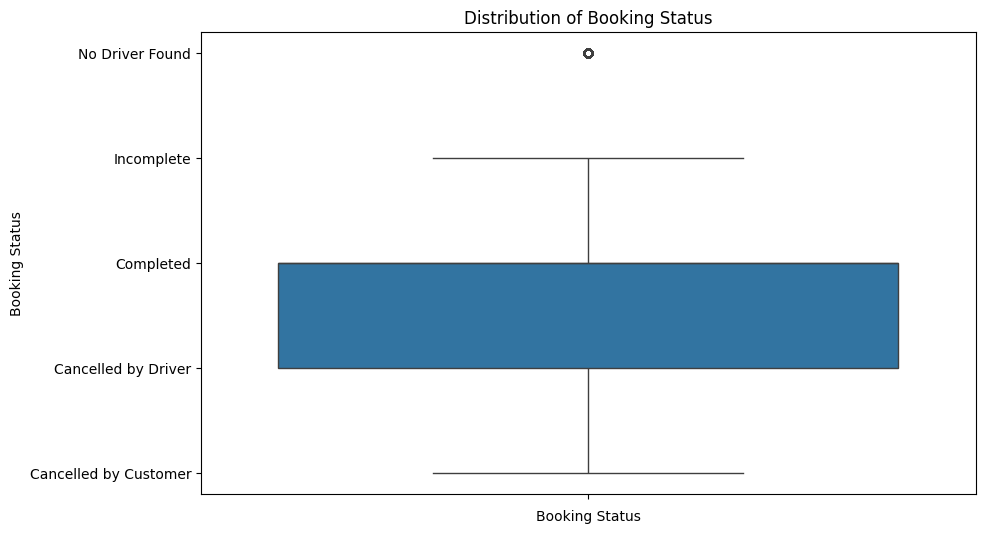

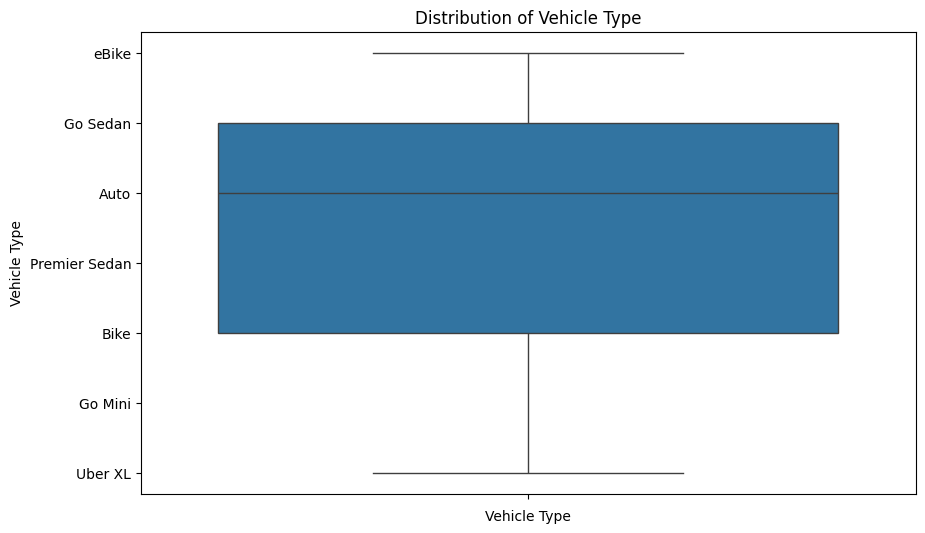

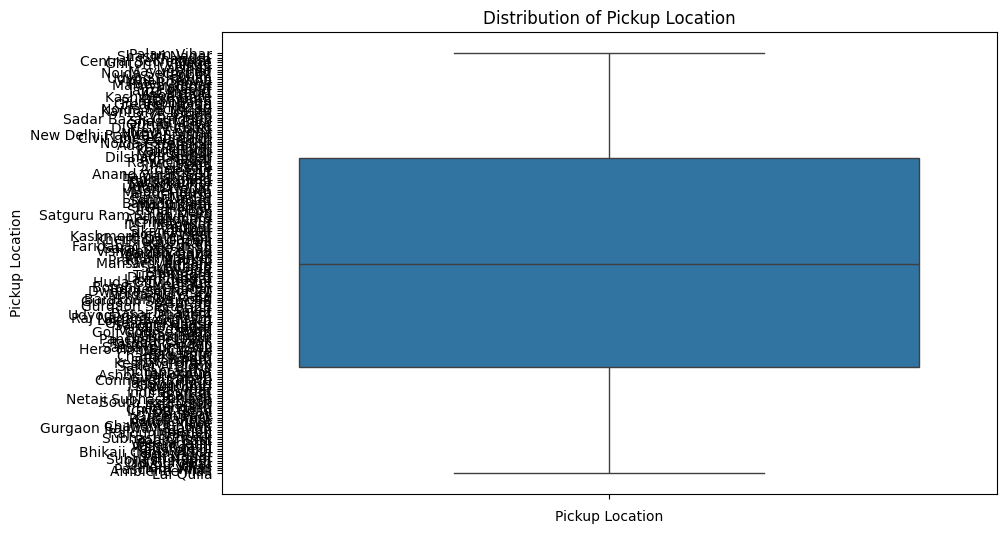

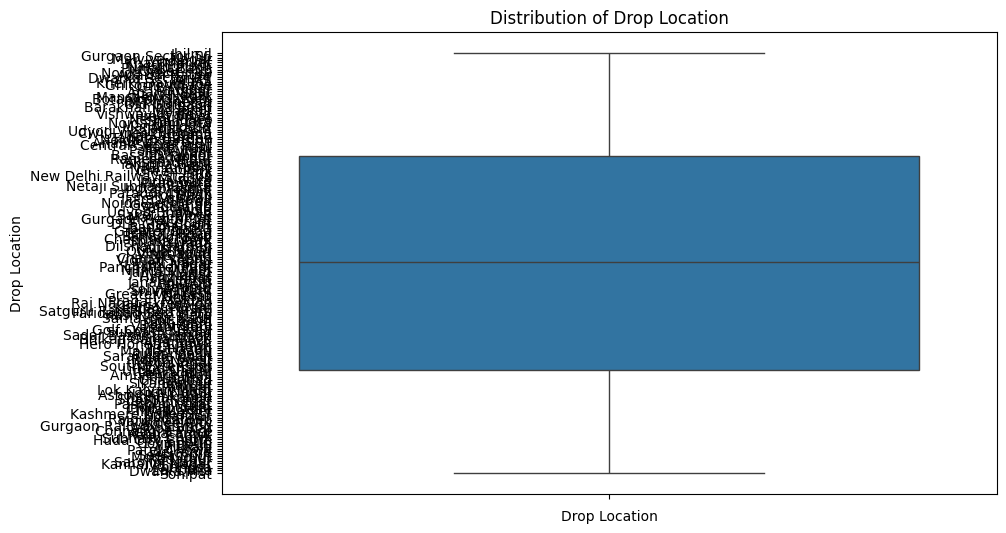

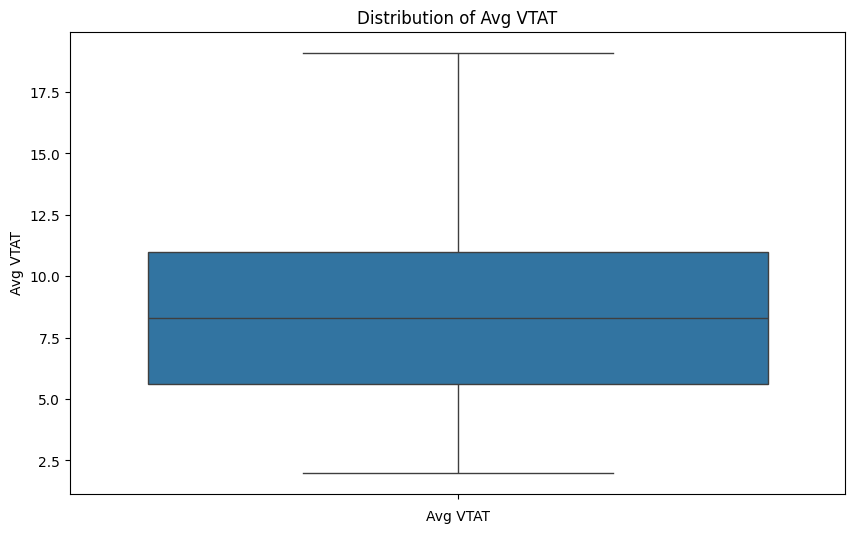

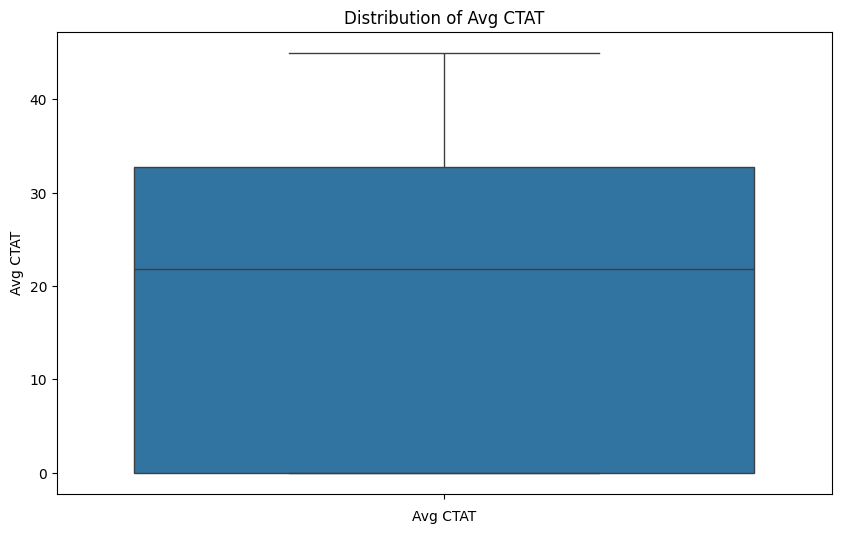

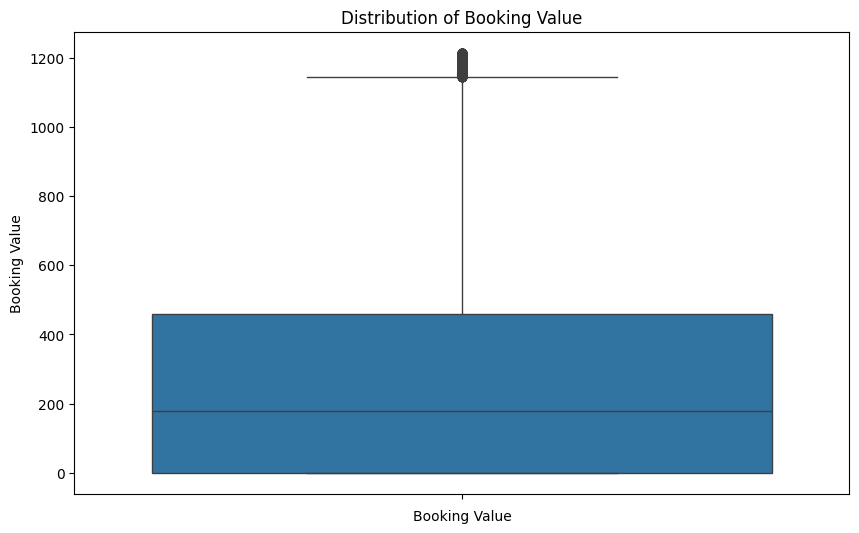

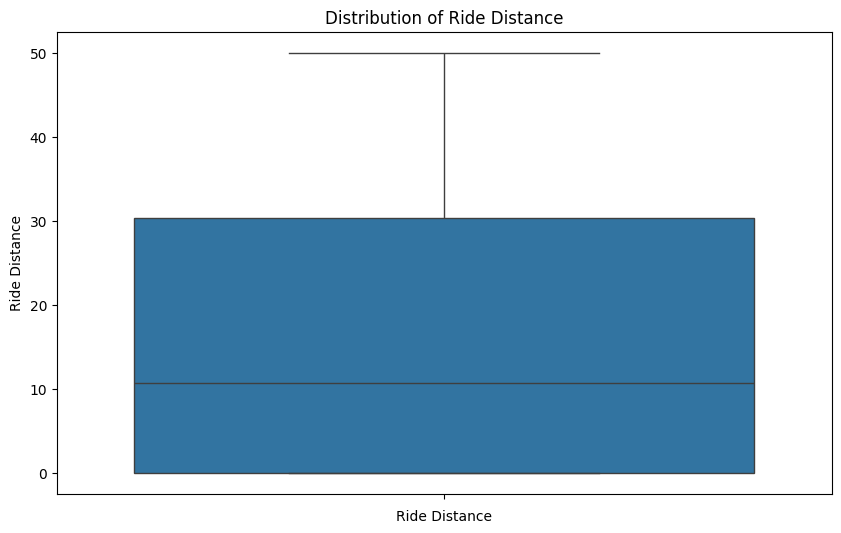

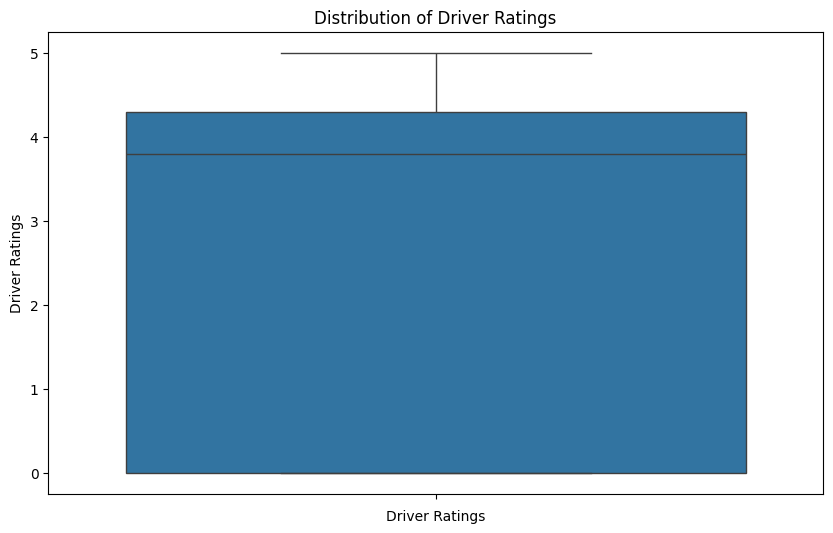

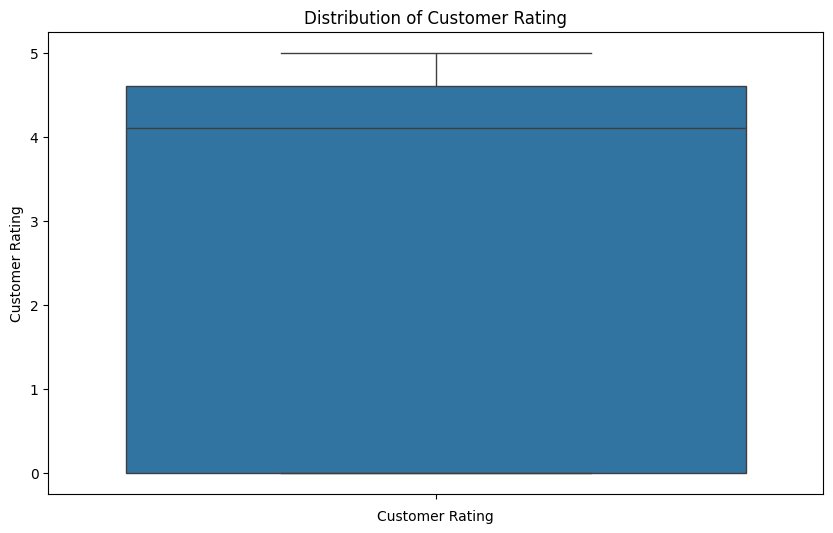

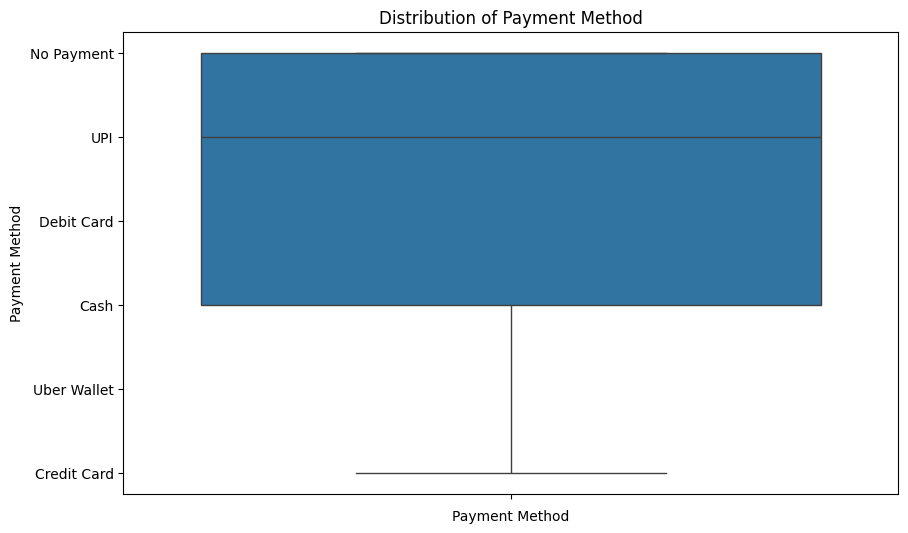

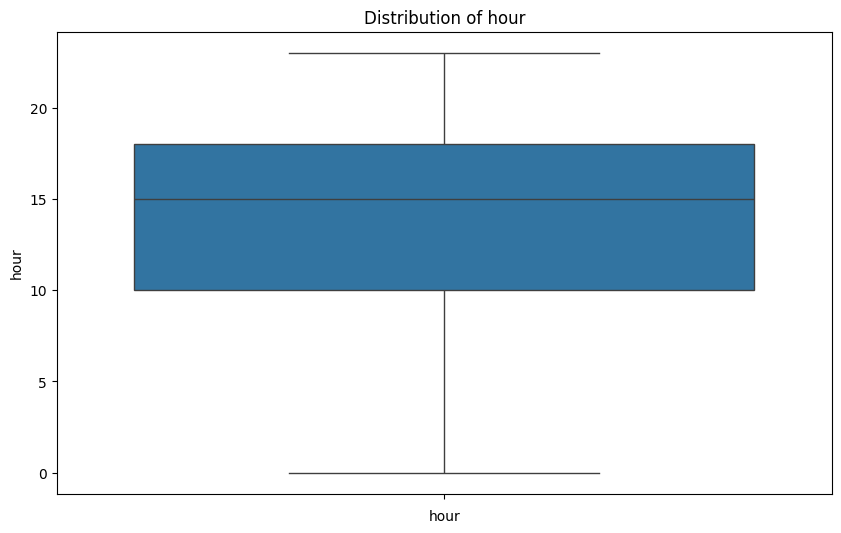

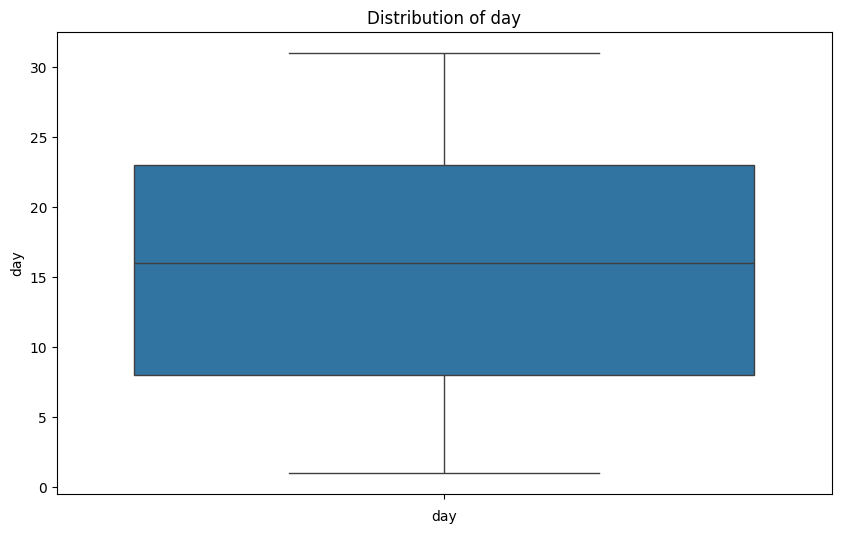

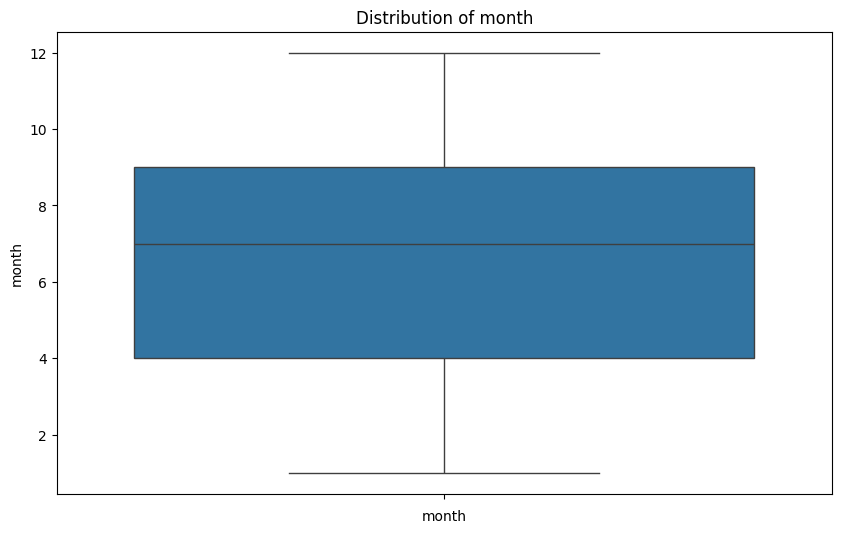

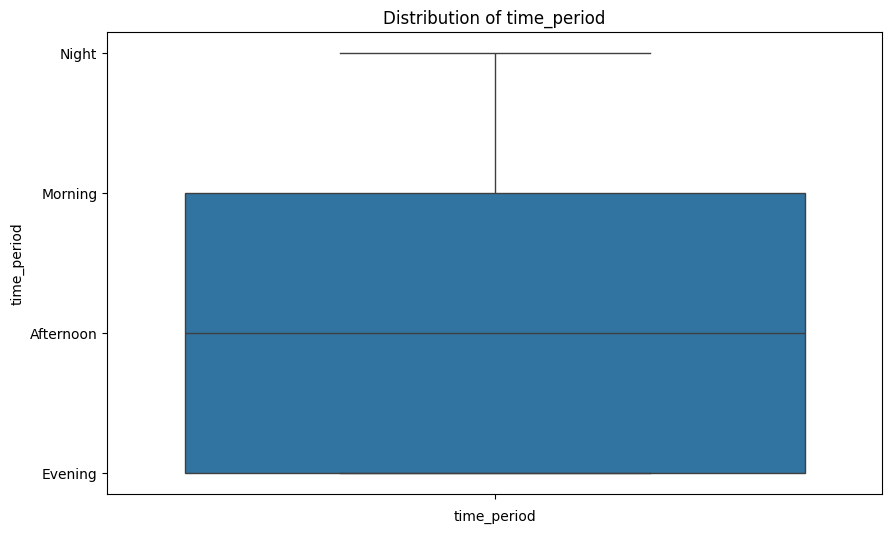

In [51]:
for col in df_clean.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(df_clean[col])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.show()

### Feature Engineering and Model Building

In [52]:
x = df_clean.drop('Booking Status', axis=1)
y = df_clean['Booking Status']

##### Note:- Tree Based Models ko scaling kijarurat nahi hoti

In [53]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)



In [54]:
# Encoding
x_train_en = pd.get_dummies(x_train, drop_first=True)
x_test_en = pd.get_dummies(x_test, drop_first=True)

x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

In [55]:
y_test

87588               Completed
80951               Completed
60070               Completed
94126     Cancelled by Driver
5367                Completed
                 ...         
112557    Cancelled by Driver
2036                Completed
24961               Completed
8730                Completed
148894        No Driver Found
Name: Booking Status, Length: 28927, dtype: object

In [56]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_le = le.fit_transform(y_train)
y_test_le = le.transform(y_test)

In [57]:
# Label Encoing Alphabetically milta hain Sab category ko
print(le.classes_)  #--> It means 0 = Cancelled by customer, 1 ='Cancelled by Driver' , 2 ='Completed, 3= 'Incomplete', 4='No Driver Found' 5= 'yese hi sabko arrange hota hain

['Cancelled by Customer' 'Cancelled by Driver' 'Completed' 'Incomplete'
 'No Driver Found']


In [58]:
y_train_le

array([3, 2, 2, ..., 1, 1, 2])

##### Trained The model

In [59]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train_en, y_train_le)
y_pred = rf_model.predict(x_test_en)


In [60]:
y_pred

array([2, 2, 2, ..., 2, 2, 4])

In [61]:
# Accuracy score
accuracy = accuracy_score(y_test_le, y_pred)
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 0.96


In [62]:
accuracy

0.9628374874684551

In [63]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test_le, y_pred)

array([[  990,  1000,     0,     0,    14],
       [    2,  5325,     0,     0,    59],
       [    0,     0, 17595,     0,     0],
       [    0,     0,     0,  1834,     0],
       [    0,     0,     0,     0,  2108]], dtype=int64)

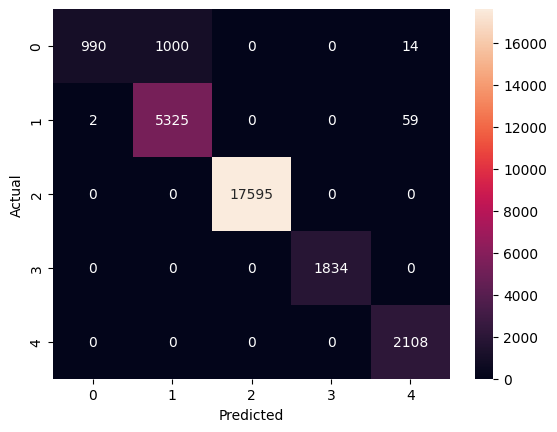

In [64]:
cm = confusion_matrix(y_test_le, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##### XGBOOST Model

In [65]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(x_train_en, y_train_le)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [66]:
y_pred_xgb = xgb_model.predict(x_test_en)
y_pred_xgb

array([2, 2, 2, ..., 2, 2, 4], dtype=int64)

In [67]:
# Accuracy score
accuracy_xgb = accuracy_score(y_test_le, y_pred_xgb)
print(f"Accuracy of XGB model: {accuracy_xgb:.2f}")

Accuracy of XGB model: 0.96


### Hyperparameter Tunning of Model

In [68]:
# Random Forest Classifier hyperparameters
rf_param_grid = {
    "n_estimators": [50, 100, 150],        # number of trees
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# XGB Classifier hyperparameters

xgb_param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2]
}

##### # Random Forest Hyperparamter Tunning

In [69]:
# from sklearn.model_selection import RandomizedSearchCV

# # Random Forest Hyperparamter Tunning
# rf = RandomForestClassifier(random_state=42)
# rf_search = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=rf_param_grid,
#     n_iter=10,       # test 10 combinations
#     cv=3,
#     scoring='accuracy',
#     n_jobs=1,
#     verbose=2,
#     random_state=42
# )
# rf_search.fit(x_train_en, y_train_le)

In [ ]:
# rf_search.best_params_

NameError: name 'rf_search' is not defined

In [ ]:
# rf_search.best_score_

np.float64(0.965075)

You see clearly accuracy score increase a little bit by doing
Hyperparameter Tunning

##### XGB Classifier Hyperparameter

In [ ]:
# XGBoost
# xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
# xgb_search = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=xgb_param_grid,
#     n_iter=10,
#     cv=3,
#     scoring='accuracy',
#     n_jobs=1,
#     verbose=2,
#     random_state=42
# )
# xgb_search.fit(x_train_en, y_train_le)

# print("Best XGB params:", xgb_search.best_params_)


# DUE TO LAPTOP MEMORY ISSUE, I AM NOT ABLE TO RUN THE XGB HYPERPARAMETER TUNNING. BUT I HAVE PROVIDED THE CODE FOR IT. YOU CAN UNCOMMENT IT AND RUN IT ON YOUR MACHINE.

# Pipeline method to build Model

In [75]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

In [76]:
cat_features = ['Vehicle Type',
'Pickup Location',
'Drop Location',
'Payment Method','time_period']

num_features = ['Avg VTAT',
'Avg CTAT',
'Booking Value',
'Ride Distance',
'Driver Ratings',
'Customer Rating',
'hour','day','month']

In [77]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144635 entries, 0 to 149999
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   Booking Status   144635 non-null  object  
 1   Vehicle Type     144635 non-null  object  
 2   Pickup Location  144635 non-null  object  
 3   Drop Location    144635 non-null  object  
 4   Avg VTAT         144635 non-null  float64 
 5   Avg CTAT         144635 non-null  float64 
 6   Booking Value    144635 non-null  float64 
 7   Ride Distance    144635 non-null  float64 
 8   Driver Ratings   144635 non-null  float64 
 9   Customer Rating  144635 non-null  float64 
 10  Payment Method   144635 non-null  object  
 11  hour             144635 non-null  int32   
 12  day              144635 non-null  int32   
 13  month            144635 non-null  int32   
 14  time_period      144635 non-null  category
dtypes: category(1), float64(6), int32(3), object(5)
memory usage: 15.0+ MB


##### Preprocessing Pipeline

In [78]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

##### Train Test Split

In [79]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    x,y,test_size=0.2,random_state=42)

In [80]:
# Label Encoding to target column
le_pipeline = LabelEncoder()
y_train1_ppl = le_pipeline.fit_transform(y_train1)
y_test1_ppl = le_pipeline.transform(y_test1)

In [81]:
y_test1_ppl

array([2, 2, 2, ..., 2, 2, 4])

##### Random Forest Pipeline

In [82]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier())
])

In [83]:
rf_pipeline.fit(X_train1,y_train1_ppl)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [84]:
rf_pred_pipeline = rf_pipeline.predict(X_test1)

In [86]:
print("RF Accuracy Through pipeline:", accuracy_score(y_test1_ppl, rf_pred_pipeline))

RF Accuracy Through pipeline: 0.962802917689356


##### Predication Checking on New data.

In [87]:
df_clean.sample(1)

,Booking Status,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,hour,day,month,time_period
144290,No Driver Found,Go Sedan,Jor Bagh,Rajouri Garden,8.3,0.0,0.0,0.0,0.0,0.0,No Payment,14,26,12,Afternoon


In [88]:
# 1st step
new_data = pd.DataFrame({
    "Ride Distance":[0],
    "Booking Value":[0],
    "Driver Ratings":[0],
    "Customer Rating":[0],
    "Vehicle Type":["Bike"],
    "Pickup Location":["New Colony"],
    "Drop Location":["Badshapur"],
    "Payment Method":["No Payment"],
    "Avg VTAT": [6.5],
    "Avg CTAT": [0],
    "hour": [21],
    "day": [13],
    "month": [3],
    "time_period": ['Evening']
})

In [89]:
# 2nd Step
new_prediction = rf_pipeline.predict(new_data)

In [90]:
# 3rd step
print("Predicted Booking Status:", le_pipeline.inverse_transform(new_prediction)[0])

Predicted Booking Status: Cancelled by Driver


##### 2nd data checking that model is working or not


In [91]:
# 1st step
new_data = pd.DataFrame({
    "Ride Distance":[0],
    "Booking Value":[0],
    "Driver Ratings":[4.5],
    "Customer Rating":[4.0],
    "Vehicle Type":["Go Sedan"],
    "Pickup Location":["Varanasi"],
    "Drop Location":["Gorakhpur"],
    "Payment Method":["Cash"],
    "Avg VTAT": [4.9],
    "Avg CTAT": [0],
    "hour": [14],
    "day": [15],
    "month": [6],
    "time_period": ['Afternoon']
})

# 2nd step
new_prediction = rf_pipeline.predict(new_data)

# 3rd step
print("Predicted Booking Status:", le_pipeline.inverse_transform(new_prediction)[0])

Predicted Booking Status: Incomplete


In [92]:
df_clean

,Booking Status,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,hour,day,month,time_period
0,No Driver Found,eBike,Palam Vihar,Jhilmil,8.3,0.0,0.0,0.00,0.0,0.0,No Payment,12,23,3,Afternoon
1,Incomplete,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0.0,0.00,0.0,0.0,UPI,18,29,11,Evening
2,Completed,Auto,Khandsa,Malviya Nagar,13.4,25.8,627.0,13.58,4.9,4.9,Debit Card,8,23,8,Morning
3,Completed,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,416.0,34.02,4.6,5.0,UPI,17,21,10,Afternoon
4,Completed,Bike,Ghitorni Village,Khan Market,5.3,19.6,737.0,48.21,4.1,4.3,UPI,22,16,9,Evening
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,Completed,Go Mini,MG Road,Ghitorni,10.2,44.4,475.0,40.08,3.7,4.1,Uber Wallet,19,11,11,Evening
149996,Completed,Go Mini,Golf Course Road,Akshardham,5.1,30.8,1093.0,21.31,4.8,5.0,UPI,15,24,11,Afternoon
149997,Completed,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,852.0,15.93,3.9,4.4,Cash,10,18,9,Morning
149998,Completed,Auto,Ghaziabad,Saidulajab,6.9,39.6,333.0,45.54,4.1,3.7,UPI,7,5,10,Morning


In [93]:
df_clean.columns

Index(['Booking Status', 'Vehicle Type', 'Pickup Location', 'Drop Location',
       'Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method', 'hour', 'day',
       'month', 'time_period'],
      dtype='object')

## Model Dump

In [94]:
import pickle

# Save the pipeline
with open('uber_model.pkl', 'wb') as f:
    pickle.dump(rf_pipeline, f)

print("Model dumped successfully!")

Model dumped successfully!


This model size is 175 MB so it make difficulty o pload on github that why I used compressed jolib to dump the model


## Label Encoder Dump

In [95]:
pickle.dump(le_pipeline, open('label_encoder.pkl','wb'))

### ML Model main and compressed

In [97]:
import joblib

joblib.dump(rf_pipeline, "model.pkl", compress=3)

['model.pkl']